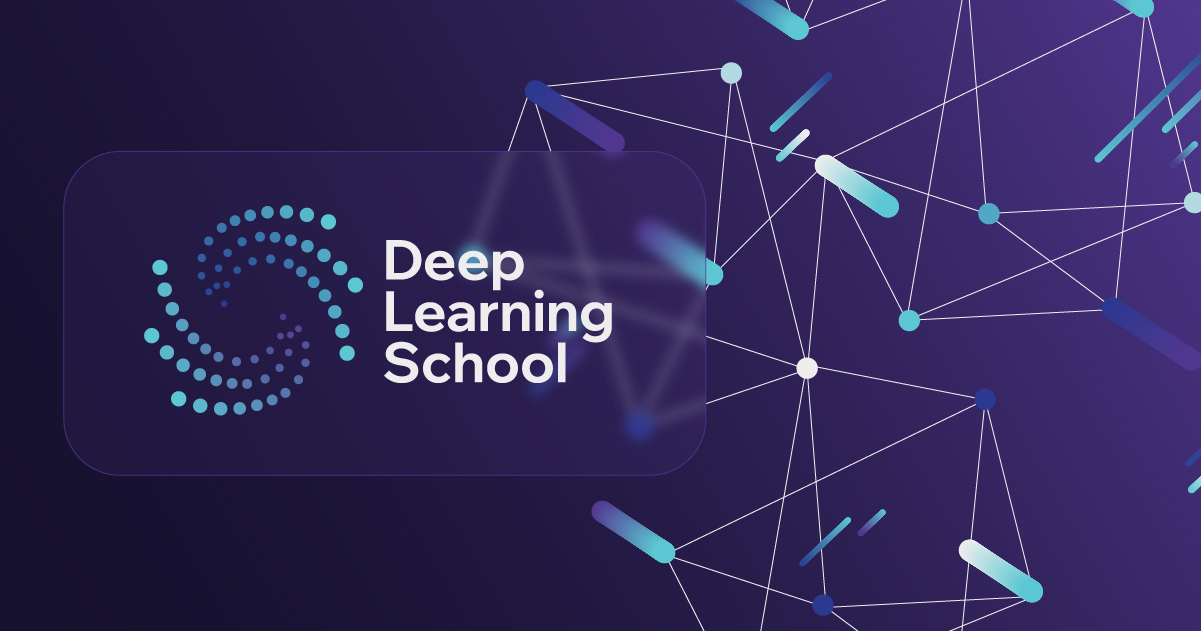


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
# !pip install kagglehub

In [9]:
import os

import imageio
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import datasets
from torchvision import transforms
import torch.nn.functional as F



%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [2]:
from pathlib import Path

In [3]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: C:\Users\k142\.cache\kagglehub\datasets\jessicali9530\lfw-dataset\versions\4


In [4]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: C:\Users\k142\.cache\kagglehub\datasets\averkij\lfw-attributes\versions\1


In [5]:
Path(images_path)

WindowsPath('C:/Users/k142/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4')

In [6]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"
DATASET_PATH = Path(images_path)
ATTRIBUTES_PATH = Path(attrs_path).joinpath("lfw_attributes.txt")

In [7]:
df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1, )
df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

> Чтение атрибутов для расшифровки

In [8]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1, )
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    # print(photo_ids.info())
    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    # Обрезка
    # dy - количество пикселей, обрезаемых сверху и снизу
    # dx - количество пикселей, обрезаемых слева и справа
    #
    # Изменение размера
    # dimx - ширина
    # dimy - высота

    images = df['photo_path'].apply(imageio.imread) \
        .apply(lambda img: img[dy:-dy, dx:-dx]) \
        .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    return images, attrs

In [9]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset(dimx=44, dimy=44)

### Посмотрим несколько картинок и соединим с атрибутами (имя)

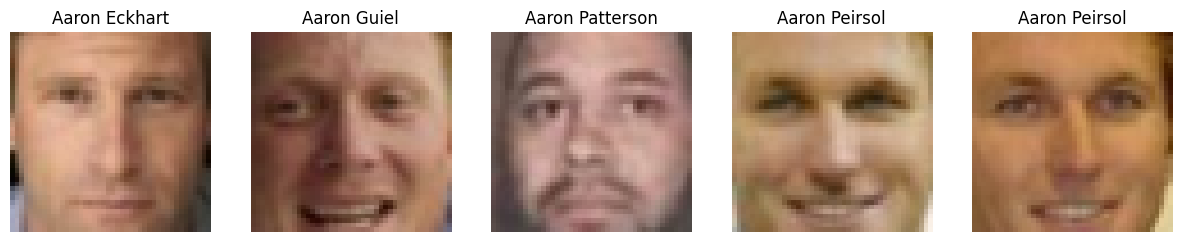

In [10]:
plt.figure(figsize=(15, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(df_attrs.iloc[i]['person'])

# plt.tight_layout()
plt.show()

In [11]:
len(images), attrs.shape[0]

(13143, 13143)


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms

class AutoencoderDataset(Dataset):
    def __init__(self, images, indices, transform=None):
        """
        Args:
            images: numpy array в формате (N, H, W, C)
            indices: индексы для выборки
            transform: преобразования (включая ToTensor())
        """
        self.indices = indices
        self.images = images[indices]  # Выбираем данные по индексам (остаётся H x W x C)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]  # Получаем изображение в формате H x W x C

        if self.transform:
            image = self.transform(image)  # Применяем преобразования (включая ToTensor())
        else:
            # Если transform=None, делаем минимальное преобразование в тензор
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0  # HWC -> CHW и [0,255] -> [0,1]

        return image, image  # Для автоэнкодера input и target одинаковы

def get_dataloaders(images, batch_size=32, train_ratio=0.8, val_ratio=0.1):
    """
    Создает DataLoader'ы для train, validation и test

    Args:
        images: numpy array в формате (N, H, W, C)
        batch_size: размер батча
        train_ratio: доля тренировочных данных
        val_ratio: доля валидационных данных
    Returns:
        train_loader, val_loader, test_loader
    """
    # Проверка формата
    if images.ndim != 4 or images.shape[3] not in {1, 3}:
        raise ValueError("Ожидается формат (N, H, W, C), где C=1 или 3")

    # Разделение данных
    n_total = len(images)
    ix = np.random.choice(n_total, n_total, False)  # Перемешанные индексы
    train_size = int(train_ratio * n_total)
    val_size = int(val_ratio * n_total)
    tr, val, ts = np.split(ix, [train_size, train_size + val_size])

    # Стандартные преобразования (HWC -> CHW + нормализация)
    transform = transforms.Compose([
        transforms.ToTensor()  # Конвертирует numpy (H x W x C) в torch (C x H x W) и нормализует [0,1]
    ])

    # Создаем датасеты
    train_dataset = AutoencoderDataset(images, tr, transform=transform)
    val_dataset = AutoencoderDataset(images, val, transform=transform)
    test_dataset = AutoencoderDataset(images, ts, transform=transform)

    # Создаем DataLoader'ы
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [13]:
train_loader, val_loader, test_loader = get_dataloaders(images, batch_size=64)

### Выведем несколько картинок из датасета

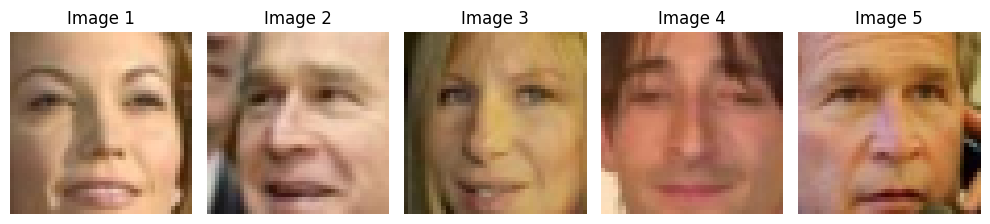

In [14]:
batch_images, _ = next(iter(train_loader))  # Автоэнкодер возвращает (input, target) — берем только input

# Создаем фигуру с 5 subplots
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

# Перебираем первые 5 картинок из батча
for i in range(5):
    single_image = batch_images[i]  # Формат: (C, H, W)

    # Если изображение нормализовано в [0, 1], преобразуем в [0, 255]
    if single_image.max() <= 1.0:
        single_image = single_image * 255.0

    # Преобразуем тензор в numpy и меняем порядок осей для matplotlib (C, H, W) -> (H, W, C)
    image_np = single_image.numpy().transpose(1, 2, 0).astype(np.uint8)

    # Отображаем изображение
    axes[i].imshow(image_np)
    axes[i].axis('off')  # Отключаем оси
    axes[i].set_title(f'Image {i+1}')

plt.tight_layout()
plt.show()

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



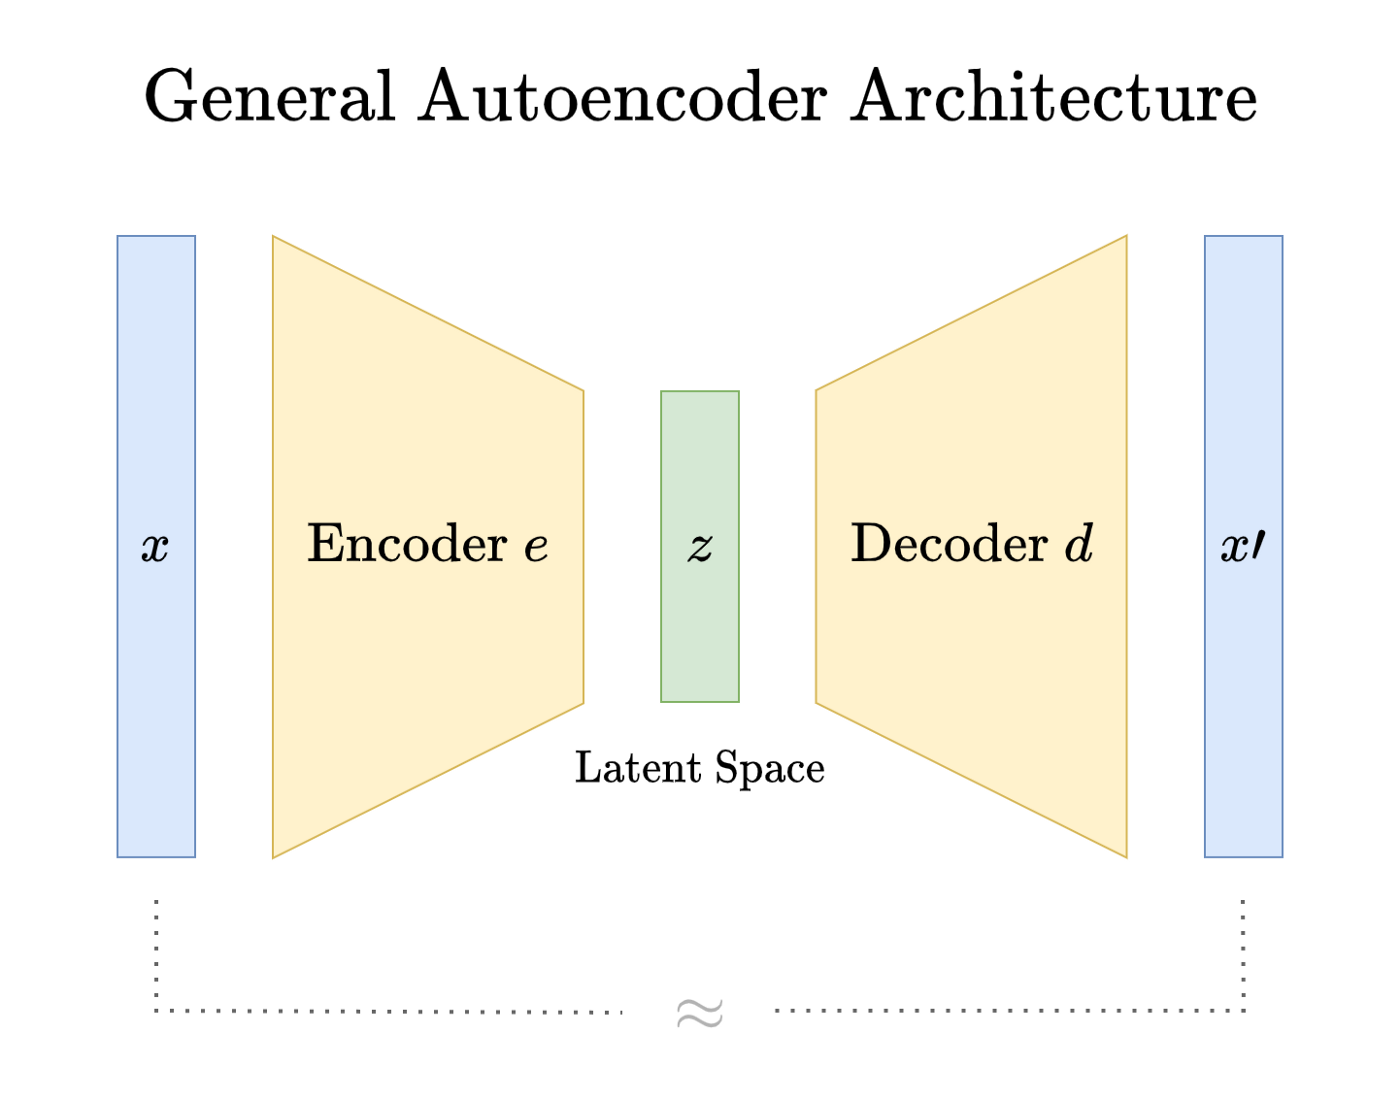

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [18]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(6*6*64, 128)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(128, 6*6*64),
            nn.ReLU(),
            nn.Unflatten(1, (64, 6, 6)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=2),
            nn.AdaptiveAvgPool2d((44, 44)),  # Принудительно устанавливаем нужный размер
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code

> Немного напутал с размерностью, поэтому пришлось поставить принудительно установить выходной размер 44x44 с помощью ***AdaptiveAvgPool2d((44, 44))***. Оставил так, чтобы проверить эту возможность.

In [19]:
model0=Autoencoder()
print(model0)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2304, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=2304, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(64, 6, 6))
    (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2))
    (8): AdaptiveAvgPool2d(output_size=(44, 44))
    (9): Sigmoid()
  )
)


## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
# Функция для обучения модели
def train_autoencoder(model, train_loader, criterion, optimizer, num_epochs, device):
    model.train()
    train_losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch_idx, (images, _) in enumerate(train_loader):
            images = images.to(device)
            optimizer.zero_grad()
            
            reconstructions, latent = model(images)
            
            loss = criterion(reconstructions, images)
            loss.backward()
            
            optimizer.step()
            epoch_loss += loss.item()
            
            if (batch_idx + 1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], '
                      f'Batch [{batch_idx+1}/{len(train_loader)}], '
                      f'Loss: {loss.item():.4f}')
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')
    
    return train_losses

In [ ]:
num_epochs = 50
train_losses = train_autoencoder(model, train_loader, criterion, optimizer, num_epochs, device)

### 1 Этап обучения

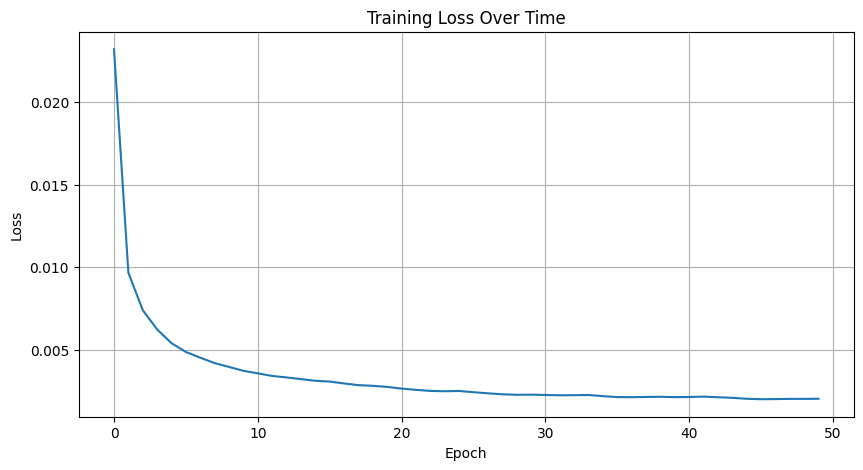

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [60]:
# torch.save(model, 'autoencoder_v1.pth')

In [23]:
# model = torch.load('autoencoder_v1.pth')

> Для обучения достаточно около 20 эпох

In [ ]:
def visualize_reconstruction(model, test_loader, device, num_images=5):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(test_loader))
        images = images[:num_images].to(device)
        
        reconstructions, _ = model(images)
        
        images = images.cpu().numpy()
        reconstructions = reconstructions.cpu().numpy()
        
        plt.figure(figsize=(12, 4))
        for i in range(num_images):
            # Оригинальное изображение
            plt.subplot(2, num_images, i + 1)
            plt.imshow(np.transpose(images[i], (1, 2, 0)))
            plt.title('Original')
            plt.axis('off')
            
            # Реконструкция
            plt.subplot(2, num_images, i + num_images + 1)
            plt.imshow(np.transpose(reconstructions[i], (1, 2, 0)))
            plt.title('Reconstructed')
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()


Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

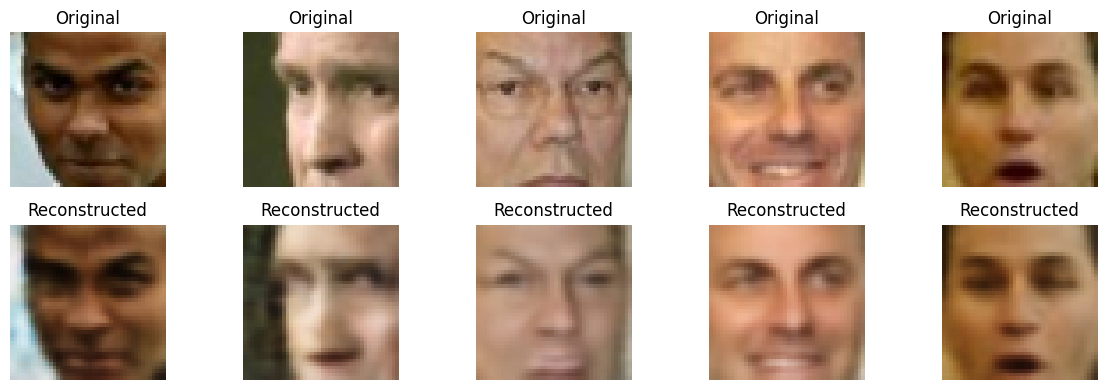

In [ ]:
# Пример использования функции визуализации
visualize_reconstruction(model, test_loader, device)

> Размерность латента - 128. Обучение 50 эпох. Качество реконструкции нормальное.

In [24]:
# Пример использования функции обучения
num_epochs = 20
train_losses = train_autoencoder(model, train_loader, criterion, optimizer, num_epochs, device)

Epoch [1/20], Batch [100/165], Loss: 0.0203
Epoch [1/20], Average Loss: 0.0245
Epoch [2/20], Batch [100/165], Loss: 0.0085
Epoch [2/20], Average Loss: 0.0094
Epoch [3/20], Batch [100/165], Loss: 0.0069
Epoch [3/20], Average Loss: 0.0073
Epoch [4/20], Batch [100/165], Loss: 0.0059
Epoch [4/20], Average Loss: 0.0062
Epoch [5/20], Batch [100/165], Loss: 0.0051
Epoch [5/20], Average Loss: 0.0054
Epoch [6/20], Batch [100/165], Loss: 0.0046
Epoch [6/20], Average Loss: 0.0048
Epoch [7/20], Batch [100/165], Loss: 0.0043
Epoch [7/20], Average Loss: 0.0045
Epoch [8/20], Batch [100/165], Loss: 0.0040
Epoch [8/20], Average Loss: 0.0042
Epoch [9/20], Batch [100/165], Loss: 0.0037
Epoch [9/20], Average Loss: 0.0040
Epoch [10/20], Batch [100/165], Loss: 0.0035
Epoch [10/20], Average Loss: 0.0038
Epoch [11/20], Batch [100/165], Loss: 0.0034
Epoch [11/20], Average Loss: 0.0036
Epoch [12/20], Batch [100/165], Loss: 0.0032
Epoch [12/20], Average Loss: 0.0034
Epoch [13/20], Batch [100/165], Loss: 0.0032
E

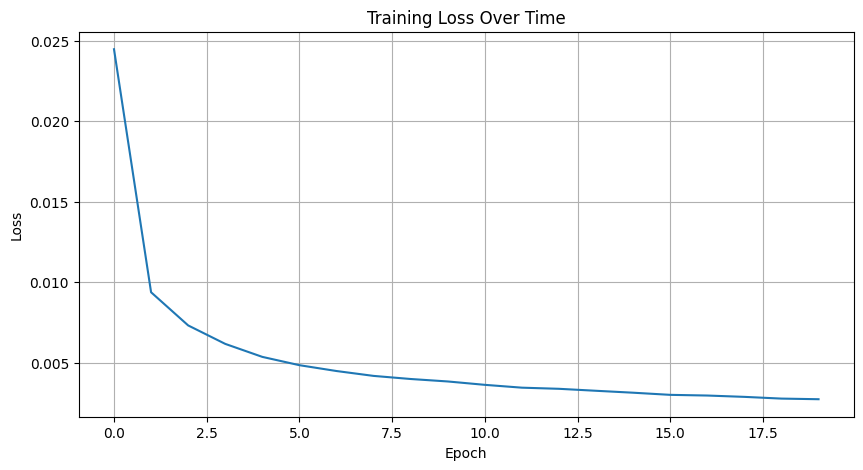

In [25]:

# Визуализация процесса обучения
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Что вы можете сказать про результат?

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [26]:
# Функция для получения статистик латентного пространства
def get_latent_stats(model, dataloader, device, num_samples=1000):
    model.eval()
    latent_vectors = []
    
    with torch.no_grad():
        for i, (images, _) in enumerate(dataloader):
            if i * images.shape[0] >= num_samples:
                break
            images = images.to(device)
            _, latent = model(images)
            latent_vectors.append(latent.cpu().numpy())
    
    latent_vectors = np.concatenate(latent_vectors, axis=0)
    mean = np.mean(latent_vectors, axis=0)
    std = np.std(latent_vectors, axis=0)
    
    return mean, std

# Функция для генерации новых изображений
def generate_images(model, num_images, latent_mean, latent_std, device):
    model.eval()
    # Генерируем случайные векторы с учетом статистик реальных данных
    z = np.random.normal(latent_mean, latent_std, (num_images, 128))
    
    with torch.no_grad():
        z = torch.FloatTensor(z).to(device)
        generated_images, _ = model.decoder(z), None
    
    return generated_images

# Функция для визуализации сгенерированных изображений
def visualize_generated(images, num_rows=5, num_cols=5):
    plt.figure(figsize=(8, 8))
    for i in range(min(num_rows * num_cols, len(images))):
        plt.subplot(num_rows, num_cols, i + 1)
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


### Визуализация новых изображений

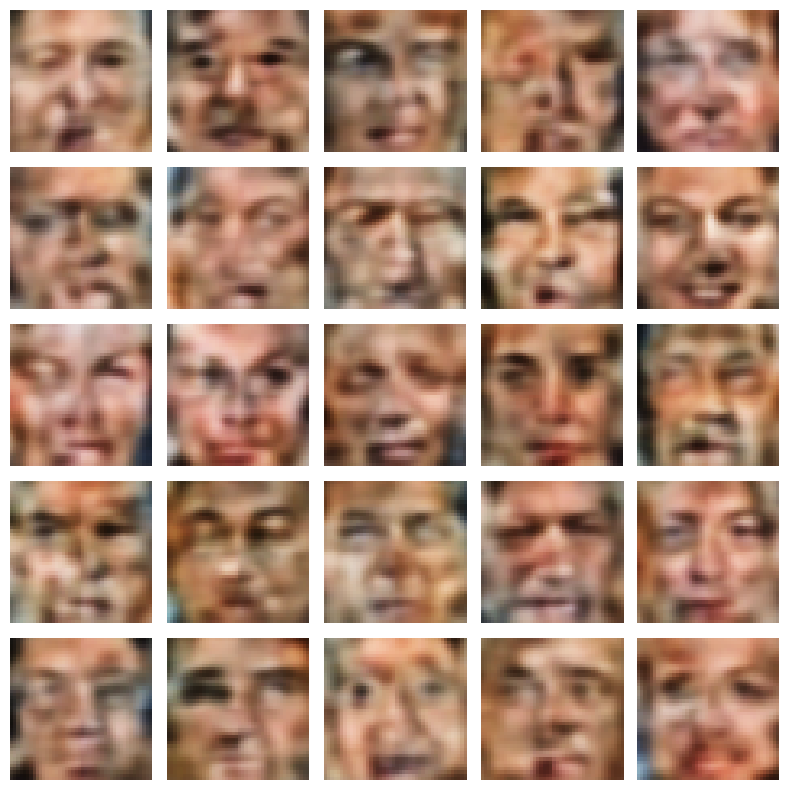

In [27]:

latent_mean, latent_std = get_latent_stats(model, train_loader, device)

num_images = 25  # 5x5 сетка
generated_images = generate_images(model, num_images, latent_mean, latent_std, device)

visualize_generated(generated_images)


> Качество не очень хорошее, но типовые характеристики лиц улавливаются

### Сделаем интерполяцию между двух точек в латентном пространстве

In [28]:
def interpolate_latent(model, z1, z2, num_steps=10, device='cuda'):
    alphas = np.linspace(0, 1, num_steps)
    interpolated_images = []
    
    with torch.no_grad():
        for alpha in alphas:
            z = torch.FloatTensor(z1 * (1 - alpha) + z2 * alpha).to(device)
            image, _ = model.decoder(z.unsqueeze(0)), None
            interpolated_images.append(image[0])
    
    return torch.stack(interpolated_images)

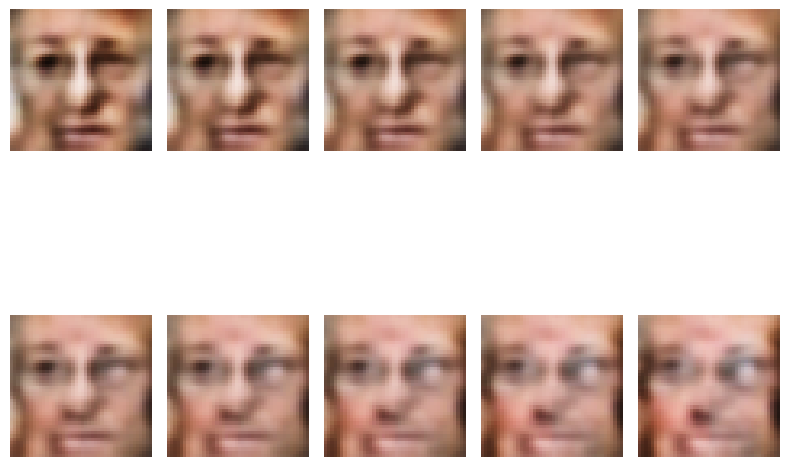

In [29]:
z1 = np.random.normal(latent_mean, latent_std, (128,))
z2 = np.random.normal(latent_mean, latent_std, (128,))

interpolated = interpolate_latent(model, z1, z2, num_steps=10, device=device)

# Визуализируем интерполяцию
visualize_generated(interpolated, num_rows=2, num_cols=5)

> Качество немного замылено, но переход от одной точки к другой явно наблюдается

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [54]:
attrs['Smiling'] = attrs['Smiling'].astype(float)

> преобразуем атрибут в число

In [55]:
attrs.Smiling.describe()

count    13143.000000
mean        -0.150700
std          1.127722
min         -2.686594
25%         -1.065725
50%         -0.320783
75%          0.766401
max          2.839994
Name: Smiling, dtype: float64

In [78]:
attrs.loc[attrs.Smiling > 2, 'Smiling'].count()

342

### Выведем изоражения с улыбками

In [36]:
idx_smiling=attrs.loc[attrs.Smiling > 2 , 'Smiling'][:5].index.to_list()

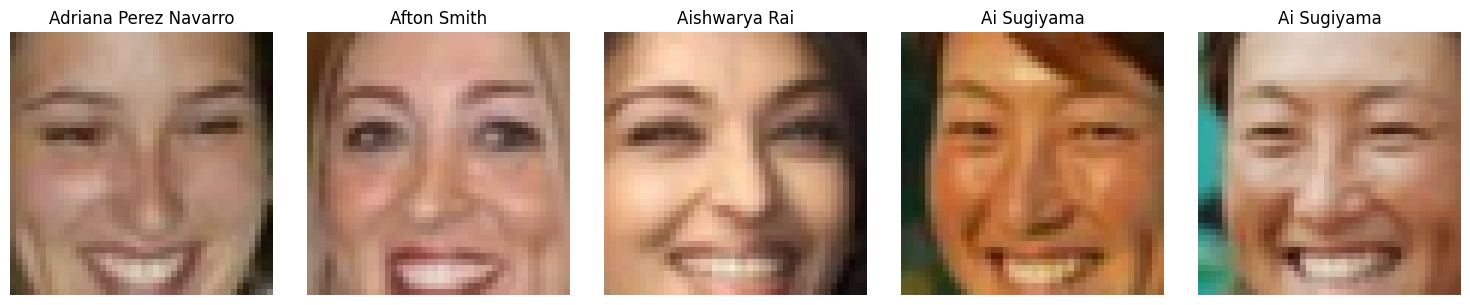

In [37]:
plt.figure(figsize=(15, 3))

ci=0
for i in idx_smiling:
    plt.subplot(1, 5, ci + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(df_attrs.iloc[i]['person'])
    ci +=1

plt.tight_layout()
plt.show()

### Выведем изображения грустными лицами

In [34]:
idx_smiling=attrs.loc[attrs.Smiling < -2 , 'Smiling'][:5].index.to_list()

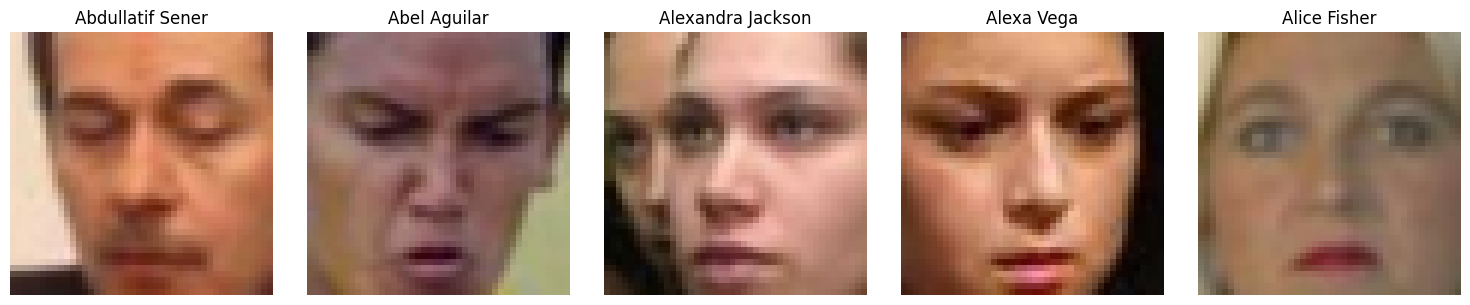

In [35]:
plt.figure(figsize=(15, 3))

ci=0
for i in idx_smiling:
    plt.subplot(1, 5, ci + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(df_attrs.iloc[i]['person'])
    ci +=1

plt.tight_layout()
plt.show()

In [52]:
idx_smiling=attrs.loc[attrs.Sunglasses > 1 , 'Sunglasses'][:5].index.to_list()

### Выведем изображения в очках

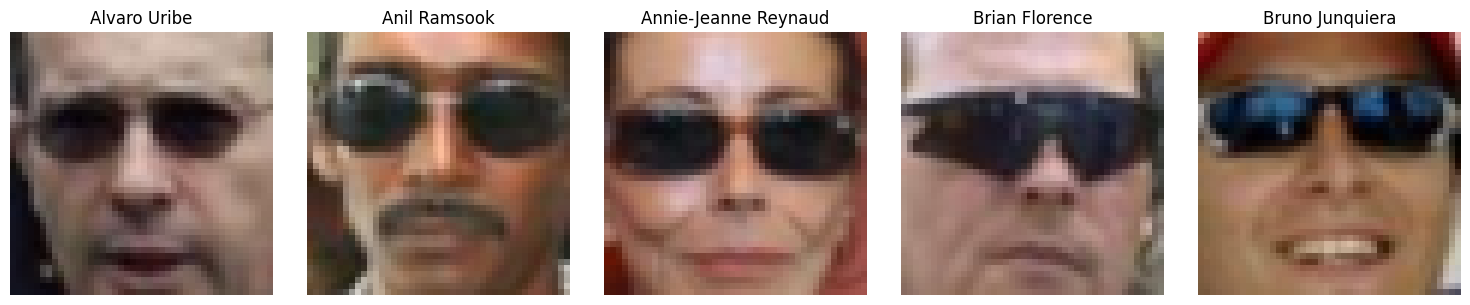

In [53]:
plt.figure(figsize=(15, 3))

ci=0
for i in idx_smiling:
    plt.subplot(1, 5, ci + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(df_attrs.iloc[i]['person'])
    ci +=1

plt.tight_layout()
plt.show()

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

In [69]:
def get_smile_vectors(model, images, attrs, attr='Smiling', treshhold=2, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Args:
        model: обученная модель автоэнкодера
        images: numpy array изображений формата (N, H, W, C)
        attrs: pandas DataFrame с атрибутами
        device: устройство для вычислений
    """

    smiling_indices = attrs.loc[attrs[attr] > treshhold, attr][:15].index.to_list()
    non_smiling_indices = attrs.loc[attrs[attr] < -2, attr][:15].index.to_list()
    
    # Преобразуем изображения в тензоры и меняем порядок размерностей NHWC -> NCHW
    smiling_images = torch.FloatTensor(images[smiling_indices]).permute(0, 3, 1, 2) / 255.0
    non_smiling_images = torch.FloatTensor(images[non_smiling_indices]).permute(0, 3, 1, 2) / 255.0
    
    model = model.to(device)
    smiling_images = smiling_images.to(device)
    non_smiling_images = non_smiling_images.to(device)
    
    # 2. Получаем латентные векторы
    model.eval()
    with torch.no_grad():
        # Для 1 типа
        output_smiling = model(smiling_images)
        if isinstance(output_smiling, tuple):
            _, smiling_latent = output_smiling
        else:
            smiling_latent = output_smiling
            
        # Для 2 типа
        output_non_smiling = model(non_smiling_images)
        if isinstance(output_non_smiling, tuple):
            _, non_smiling_latent = output_non_smiling
        else:
            non_smiling_latent = output_non_smiling
    
    # 3. Вычисляем средние векторы и их разность
    mean_smiling = torch.mean(smiling_latent, dim=0)
    mean_non_smiling = torch.mean(non_smiling_latent, dim=0)
    smile_vector = mean_smiling - mean_non_smiling
    
    return smile_vector, smiling_indices, non_smiling_indices

def add_smile(model, image, smile_vector, alpha=1.0, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Добавляет атрибут изображению
    
    Args:
        model: обученная модель автоэнкодера
        image: исходное изображение (numpy array формата H x W x C)
        smile_vector: вектор улыбки
        alpha: коэффициент интенсивности улыбки
        device: устройство для вычислений
    """
    image_tensor = torch.FloatTensor(image).unsqueeze(0).permute(0, 3, 1, 2) / 255.0
    image_tensor = image_tensor.to(device)
    model = model.to(device)
    smile_vector = smile_vector.to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        if isinstance(output, tuple):
            _, latent = output
        else:
            latent = output
            
        new_latent = latent + alpha * smile_vector
        generated_image = model.decoder(new_latent)
    
    result = generated_image.cpu().squeeze(0).permute(1, 2, 0).numpy()
    result = np.clip(result * 255, 0, 255).astype(np.uint8)
    
    return result

def visualize_smile_transformation(model, images, attrs, attr='Smiling', treshhold=2, n_samples=5):
    """
    Визуализирует процесс добавления улыбки к изображениям
    
    Args:
        model: обученная модель автоэнкодера
        images: numpy array изображений
        attrs: pandas DataFrame с атрибутами
        n_samples: количество примеров для визуализации
    """
    import matplotlib.pyplot as plt
    
    # Получаем вектор улыбки
    smile_vector, _, _ = get_smile_vectors(model, images, attrs, attr, treshhold)
    
    # Выбираем 1 тип
    non_smiling_indices = attrs.loc[attrs[attr] < -2,  attr][:n_samples].index.to_list()
    
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5*n_samples))
    
    for i, idx in enumerate(non_smiling_indices):
        # Исходное изображение
        axes[i, 0].imshow(images[idx])
        axes[i, 0].set_title('Оригинал')
        axes[i, 0].axis('off')
        
        # Альфа 0.5
        with_smile_05 = add_smile(model, images[idx], smile_vector, alpha=0.5)
        axes[i, 1].imshow(with_smile_05)
        axes[i, 1].set_title('Улыбка (α=0.5)')
        axes[i, 1].axis('off')
        
        # Альфа 1.0
        with_smile_10 = add_smile(model, images[idx], smile_vector, alpha=1.0)
        axes[i, 2].imshow(with_smile_10)
        axes[i, 2].set_title('Улыбка (α=1.0)')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show() 

In [70]:
get_smile_vectors(model, images, attrs, attr='Smiling', treshhold=2)

(tensor([-0.0138,  0.5528,  0.4414, -0.4814, -0.5479,  0.2789,  1.4614,  0.1529,
          1.1174,  1.7284, -0.5132, -0.3974,  1.6948, -1.3433,  1.5766,  0.1819,
         -1.0668, -0.2470,  0.4693,  1.1304, -1.7321, -0.1119, -0.1823, -1.2855,
          0.8052,  0.9756, -0.0181,  0.8279, -0.7698, -0.7028, -1.6297, -0.5980,
         -0.6379, -0.3280, -0.6316, -1.0263,  0.1830,  0.0831,  0.3334,  0.3939,
         -1.4028, -1.2085, -1.1107, -1.4644,  1.8751, -0.3241, -1.0025, -1.3799,
         -0.4930, -0.0743, -0.3587,  0.3759, -0.3553,  0.4018,  1.1800,  0.2091,
         -0.7224,  0.7943,  0.7712, -0.5273, -0.5040,  1.0200, -0.5455,  0.2054,
         -0.1882, -0.7528, -0.5678, -0.4842, -0.7234, -0.1275, -0.7459,  0.1347,
         -0.2876, -0.1370, -1.5737, -0.4301,  0.0757, -1.1922,  0.5825, -0.7156,
          0.0462, -0.8594, -0.0861, -0.5967, -0.7838,  0.5367,  0.5355,  0.2413,
          0.8549, -0.2797, -0.3739, -0.9874, -0.5867,  1.2443, -0.9493,  1.2673,
         -0.9105, -0.5915, -

### Пририсуем улыбки

Количество улыбающихся людей: 15
Количество не улыбающихся людей: 15
Размерность вектора улыбки: torch.Size([128])


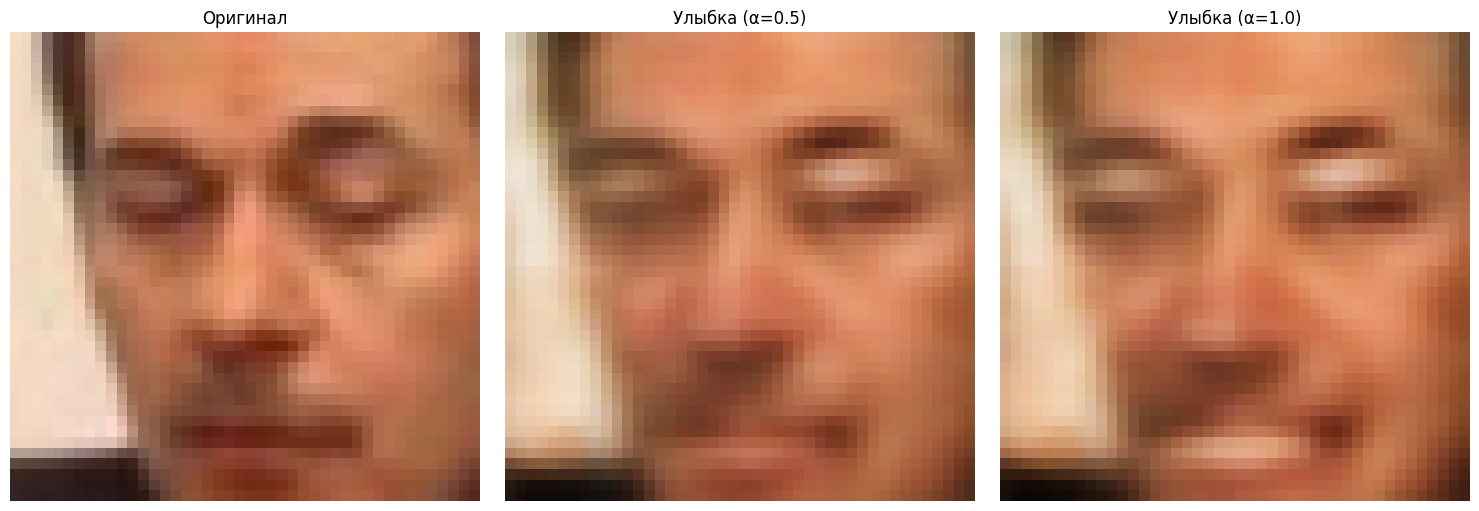


Визуализация трансформации для 5 изображений:


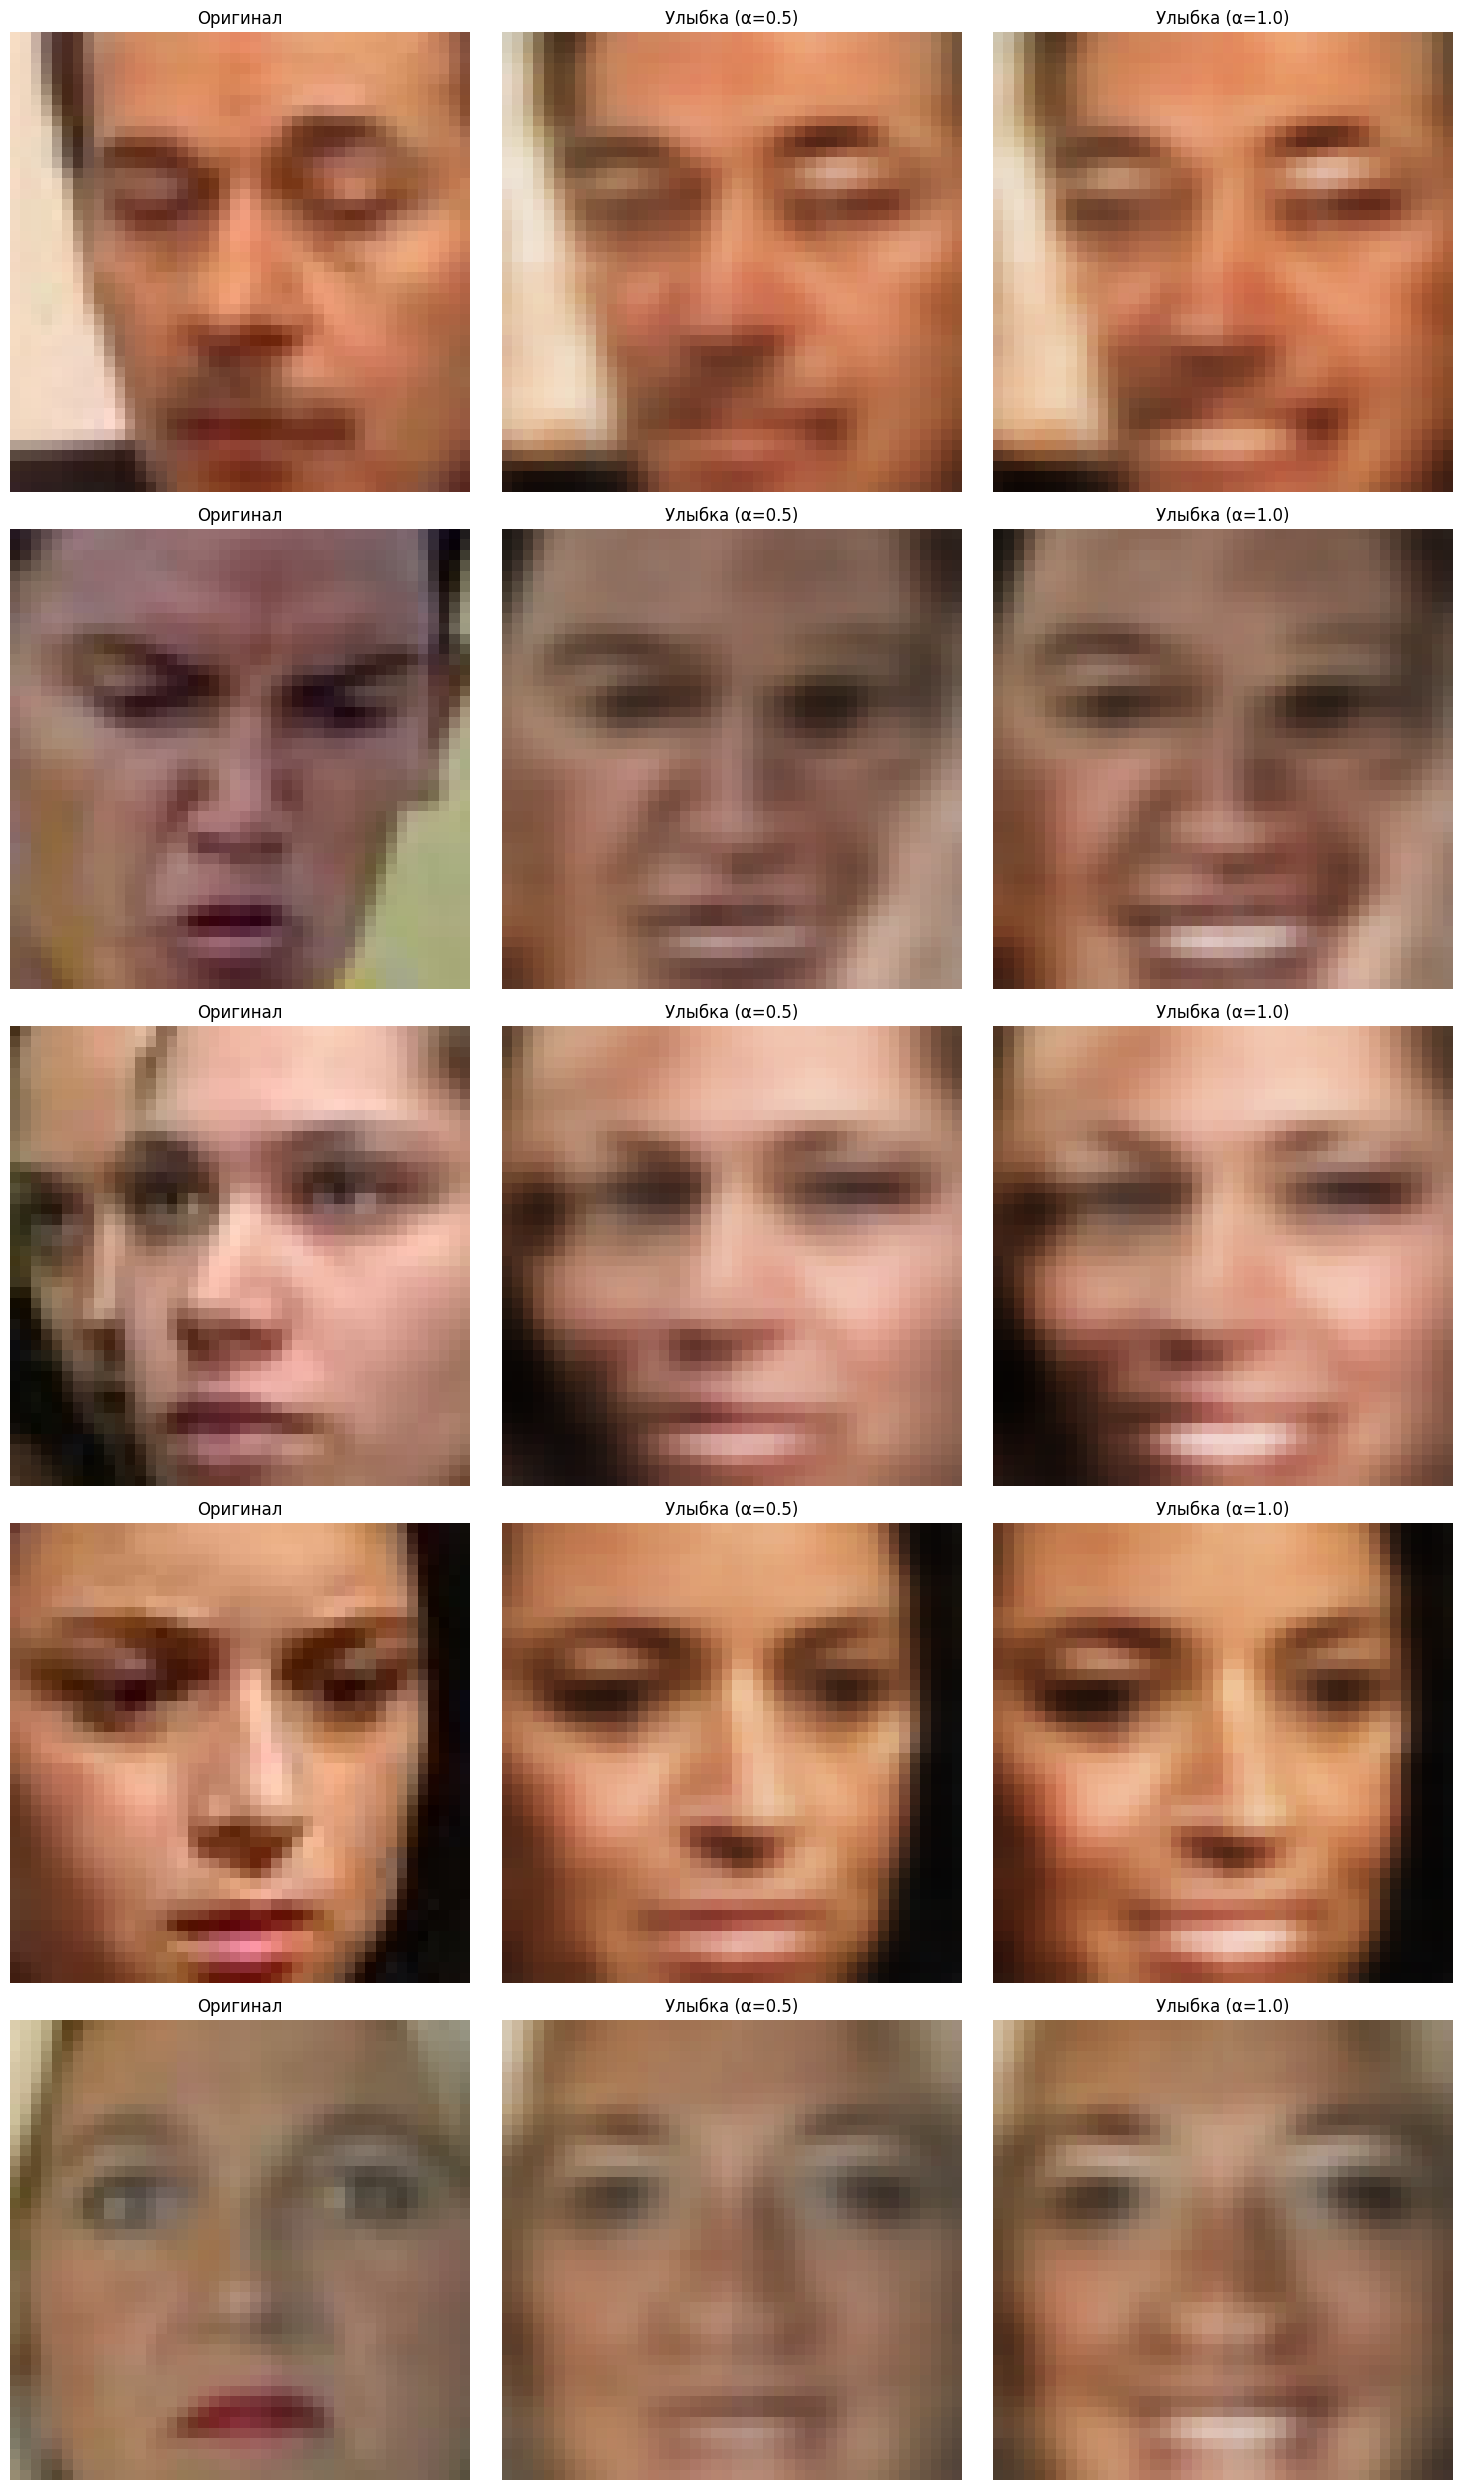

In [71]:
# Получение вектора улыбки
try:
    smile_vector, smiling_indices, non_smiling_indices = get_smile_vectors(model, images, attrs)
    print(f"Количество улыбающихся людей: {len(smiling_indices)}")
    print(f"Количество не улыбающихся людей: {len(non_smiling_indices)}")
    print(f"Размерность вектора улыбки: {smile_vector.shape}")
except Exception as e:
    print(f"Ошибка при получении вектора улыбки: {e}")

# Пример добавления улыбки к одному изображению
try:
    test_idx = non_smiling_indices[0]
    
    # Создаем сетку для визуализации
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Исходное изображение
    axes[0].imshow(images[test_idx])
    axes[0].set_title('Оригинал')
    axes[0].axis('off')
    
    # Добавляем улыбку с разной интенсивностью
    for i, alpha in enumerate([0.5, 1.0]):
        result = add_smile(model, images[test_idx], smile_vector, alpha=alpha)
        axes[i+1].imshow(result)
        axes[i+1].set_title(f'Улыбка (α={alpha})')
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Ошибка при добавлении улыбки к одному изображению: {e}")

# Визуализация нескольких примеров
try:
    print("\nВизуализация трансформации для 5 изображений:")
    visualize_smile_transformation(model, images, attrs, n_samples=5)
except Exception as e:
    print(f"Ошибка при визуализации нескольких примеров: {e}")

> Сделать улыбки для грусных лиц это очень сложно, но модель справилась! Преемственность средняя, но модель очень сильно пыталась

### Пририсуем очки

Количество улыбающихся людей: 15
Количество не улыбающихся людей: 15
Размерность вектора улыбки: torch.Size([128])


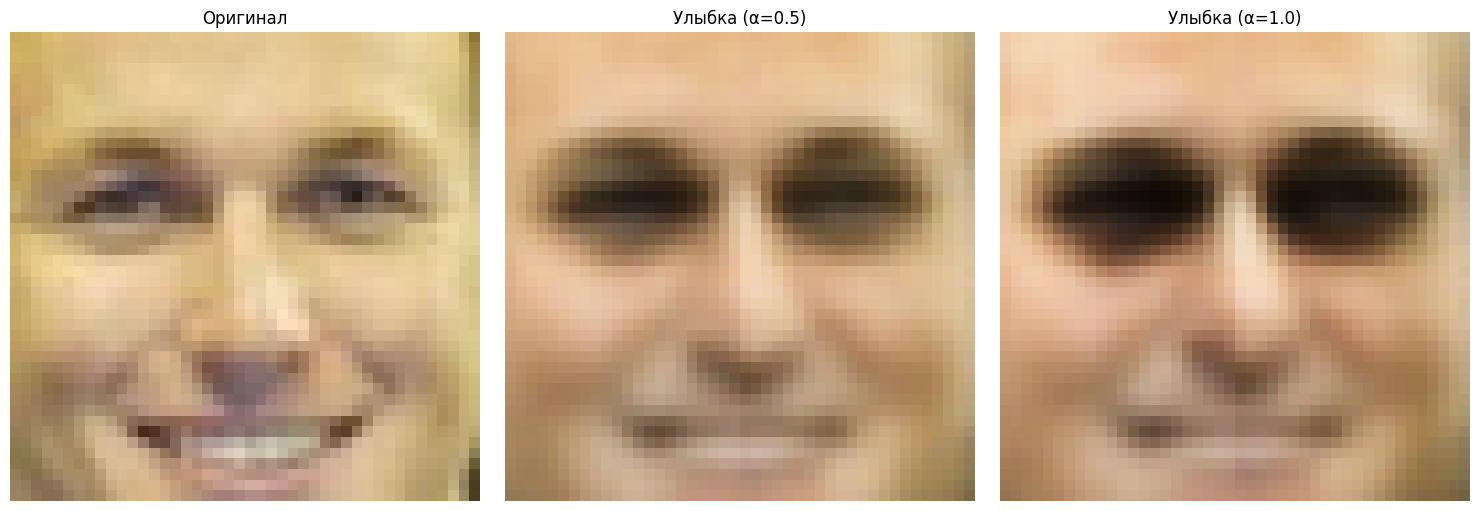


Визуализация трансформации для 5 изображений:


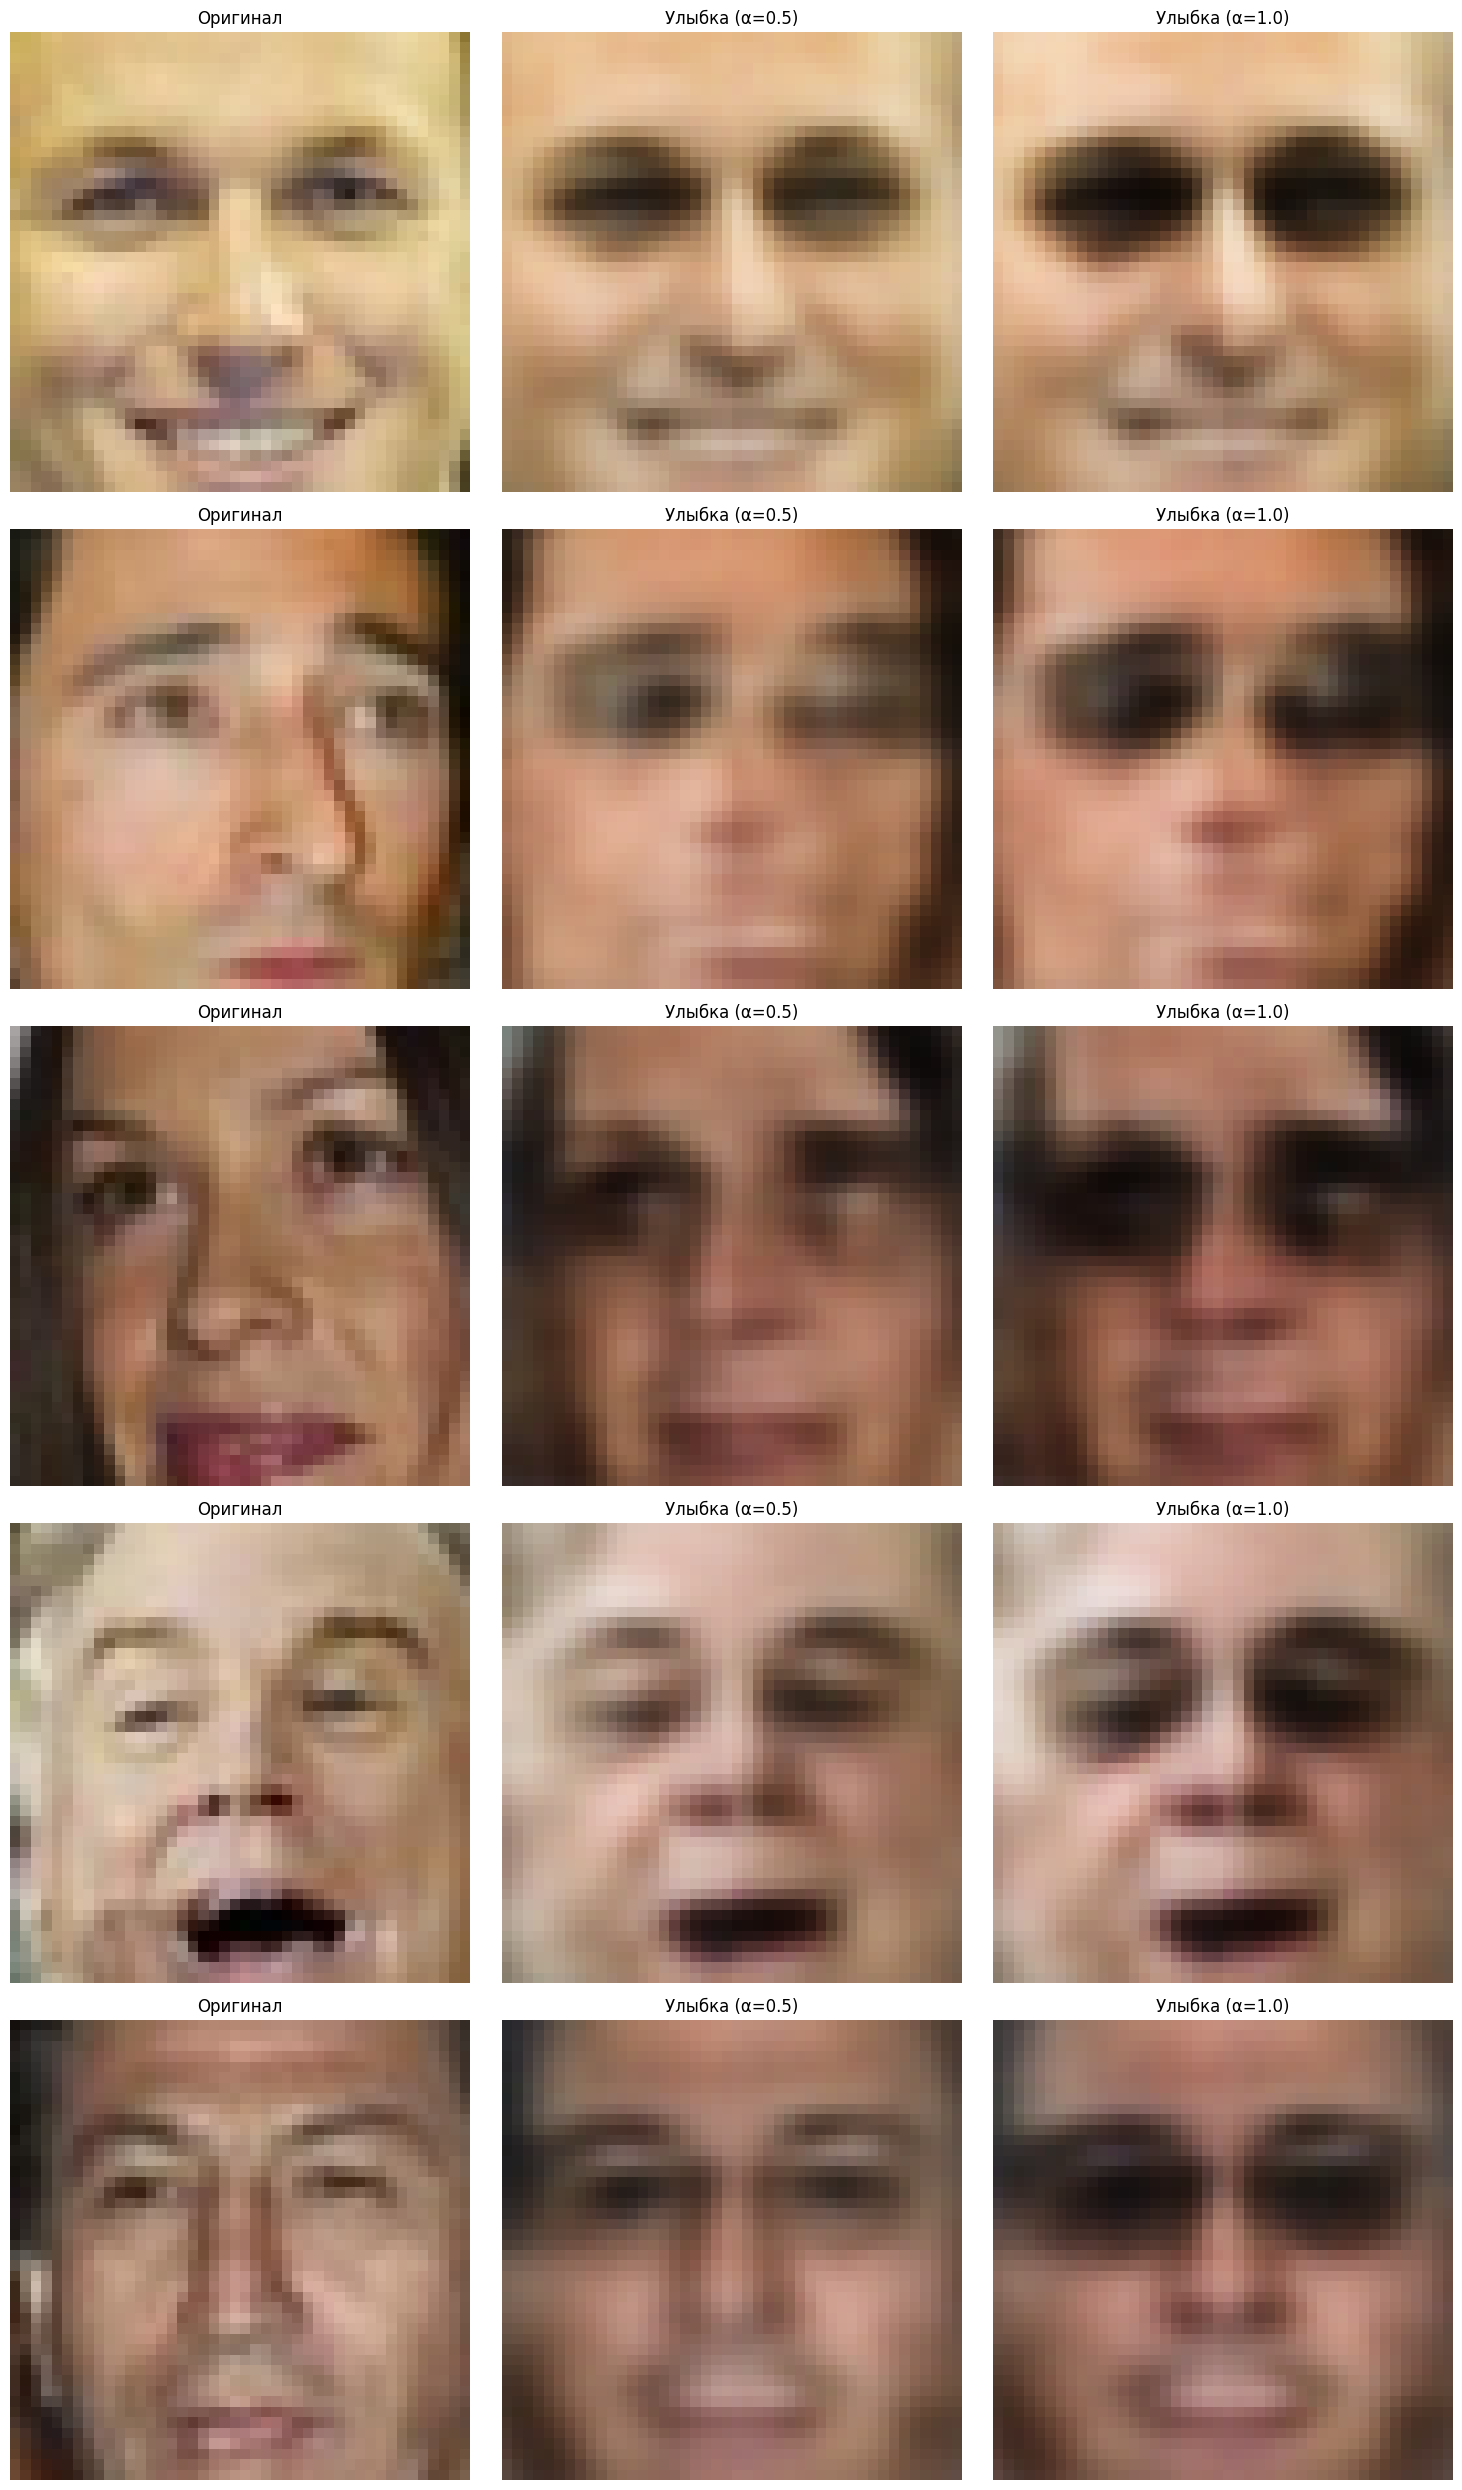

In [73]:
try:
    smile_vector, smiling_indices, non_smiling_indices = get_smile_vectors(model, images, attrs, attr='Sunglasses', treshhold=1)
    print(f"Количество улыбающихся людей: {len(smiling_indices)}")
    print(f"Количество не улыбающихся людей: {len(non_smiling_indices)}")
    print(f"Размерность вектора улыбки: {smile_vector.shape}")
except Exception as e:
    print(f"Ошибка при получении вектора улыбки: {e}")

try:
    test_idx = non_smiling_indices[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(images[test_idx])
    axes[0].set_title('Оригинал')
    axes[0].axis('off')
    
    for i, alpha in enumerate([0.5, 1.0]):
        result = add_smile(model, images[test_idx], smile_vector, alpha=alpha)
        axes[i+1].imshow(result)
        axes[i+1].set_title(f'Улыбка (α={alpha})')
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Ошибка при добавлении улыбки к одному изображению: {e}")

# Визуализация нескольких примеров
try:
    print("\nВизуализация трансформации для 5 изображений:")
    visualize_smile_transformation(model, images, attrs,  attr='Sunglasses', treshhold=1, n_samples=5)
except Exception as e:
    print(f"Ошибка при визуализации нескольких примеров: {e}")

> Очки пририсованны, но окончательные лица имеют только относительную схожесть на оригинал

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [ ]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=False)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [ ]:
class VariationalEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)
        self.linear3 = nn.Linear(512, latent_dims)

        self.N = torch.distributions.Normal(0, 1)
        self.kl = 0  # Инициализируем KL дивергенцию

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu = self.linear2(x)
        sigma = torch.exp(self.linear3(x))
        z = mu + sigma * self.N.sample(mu.shape)
        #     часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1/2).sum()
        return z

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = torch.sigmoid(self.linear2(z))
        return z.reshape((-1, 1, 28, 28))

In [ ]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = VariationalEncoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

И обучим модель:

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())
    autoencoder.train()  # Переводим модель в режим обучения

    for epoch in range(epochs):
        epoch_loss = 0.0  # Для накопления loss за эпоху
        num_batches = 0   # Счётчик батчей

        for x, y in data:
            x = x.to(device)  # GPU
            opt.zero_grad()
            x_hat = autoencoder(x)
            # часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
            loss = ((x - x_hat)**2).sum()  + autoencoder.encoder.kl # MSE loss
            loss.backward()
            opt.step()

            epoch_loss += loss.item()  # Накопление loss
            num_batches += 1

        # Выводим средний loss за эпоху
        avg_loss = epoch_loss / num_batches
        print(f'Epoch: {epoch}, Loss: {avg_loss:.4f}')

    return autoencoder

### Обучение VAE

In [ ]:
latent_dims = 2

> Эксперимент с рвзмерностью 2. Если изображения будут приемлемого качества, то можно будет изобразить распределение без преобразования

In [ ]:
vae = VariationalAutoencoder(latent_dims).to(device) # GPU
vae = train(vae, train_loader)

Epoch: 0, Loss: 1432.8121
Epoch: 1, Loss: 1332.2174
Epoch: 2, Loss: 1303.4748
Epoch: 3, Loss: 1285.2049
Epoch: 4, Loss: 1271.5059
Epoch: 5, Loss: 1260.3145
Epoch: 6, Loss: 1251.8201
Epoch: 7, Loss: 1245.3517
Epoch: 8, Loss: 1238.5104
Epoch: 9, Loss: 1232.7947
Epoch: 10, Loss: 1228.4932
Epoch: 11, Loss: 1224.5990
Epoch: 12, Loss: 1220.4121
Epoch: 13, Loss: 1217.0061
Epoch: 14, Loss: 1213.4526
Epoch: 15, Loss: 1211.3720
Epoch: 16, Loss: 1208.5675
Epoch: 17, Loss: 1205.9446
Epoch: 18, Loss: 1203.4093
Epoch: 19, Loss: 1201.4429


Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

In [ ]:
def plot_reconstructed(autoencoder, r0=(-5, 10), r1=(-10, 5), n=12):
    w = 28
    img = np.zeros((n*w, n*w))
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            z = torch.Tensor([[x, y]]).to(device)
            x_hat = autoencoder.decoder(z)
            x_hat = x_hat.reshape(28, 28).to('cpu').detach().numpy()
            img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat
    plt.imshow(img, extent=[*r0, *r1])

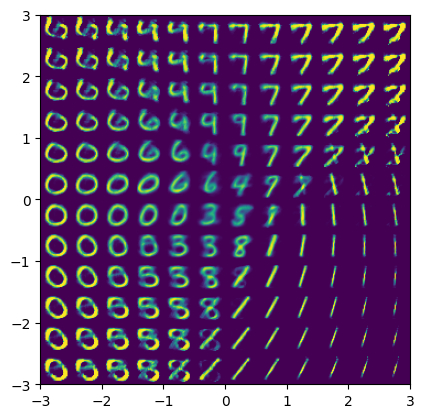

In [ ]:
plot_reconstructed(vae, r0=(-3, 3), r1=(-3, 3))

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [ ]:
def generate_images(model, n_samples=16, latent_dim=2, device='cpu'):
    """
    Генерация изображений из латентного пространства

    """
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim).to(device)
        
        generated_images = model.decoder(z)
        
        generated_images = generated_images.cpu().numpy()
        
        grid_size = int(np.sqrt(n_samples))
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(5, 5))
        
        for i in range(grid_size):
            for j in range(grid_size):
                idx = i * grid_size + j
                if idx < n_samples:
                    axes[i, j].imshow(generated_images[idx].squeeze(), cmap='gray')
                    axes[i, j].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        return z    



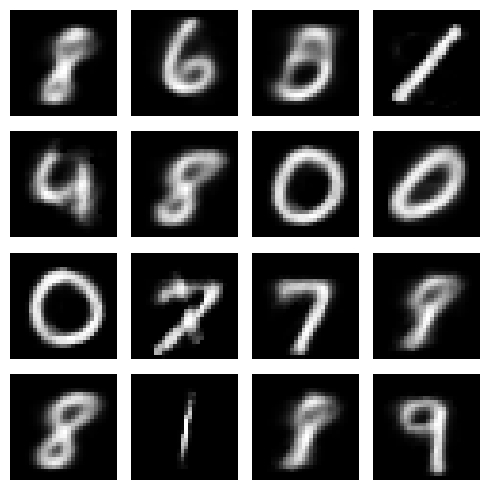

In [ ]:
dots=generate_images(vae, n_samples=16, latent_dim=2, device=device)

> Все изображения нормально идентифицируются. Всего 1 - 2 немного сбойные.

> Запомним эти точки для отображения в латентном пространстве

Интерполяция. Возьмем 2 точки в латентном пространстве и сделаем интерполяцию между ними с выводом изображения

In [ ]:
def interpolate(autoencoder, x_1, x_2, n=12):
    z_1 = autoencoder.encoder(x_1)
    z_2 = autoencoder.encoder(x_2)
    z = torch.stack([z_1 + (z_2 - z_1)*t for t in np.linspace(0, 1, n)])
    interpolate_list = autoencoder.decoder(z)
    interpolate_list = interpolate_list.to('cpu').detach().numpy()

    w = 28
    img = np.zeros((w, n*w))
    for i, x_hat in enumerate(interpolate_list):
        img[:, i*w:(i+1)*w] = x_hat.reshape(28, 28)
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])

In [ ]:
x, y = next(iter(train_loader))
x_1 = x[y == 1][1].to(device) # find a 1
x_2 = x[y == 0][1].to(device) # find a 0

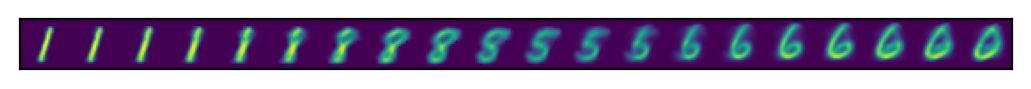

In [ ]:
interpolate(vae, x_1, x_2, n=20)

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [ ]:
def plot_latent(autoencoder, data, num_batches=100):
    for i, (x, y) in enumerate(data):
        z = autoencoder.encoder(x.to(device))
        z = z.to('cpu').detach().numpy()
        plt.scatter(z[:, 0], z[:, 1], c=y, cmap='tab10')
        if i > num_batches:
            plt.colorbar()
            break
    for i, (x,y) in enumerate(dots):
        plt.scatter(x, y, c='blue',  marker='x')
        plt.annotate(f'{i}', (x, y), xytext=(5, 5),    textcoords='offset points')


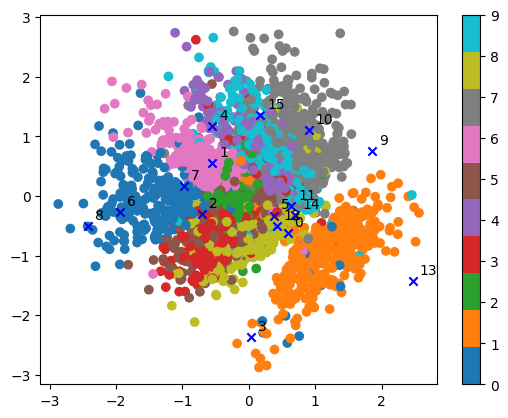

In [ ]:
plot_latent(vae, train_loader)

> Наблюдаются отдельные кластеры для цифр. Очень хорошо отделены цифры "1". Очень сильно пересекаются кластеры "4" и "9"

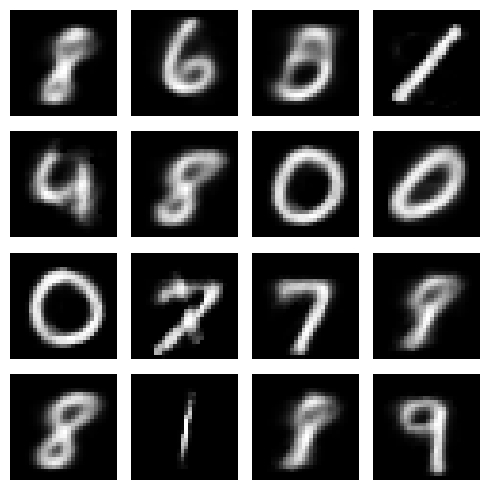

In [ ]:
# Случайные числа из латентного пространства

> Нанесены на график числа из латентного пространства.

<pre>
00 01 02 03
04 05 06 07
08 09 10 11
12 13 14 15
</pre>

> картинки с индексами 03, 13, 14 имеют плохое начертание

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [ ]:
class ConditionalVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, num_classes):
        super(ConditionalVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # Энкодер
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + num_classes, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        
        # Слои для mu и log_var
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_var = nn.Linear(256, latent_dim)
        
        # Декодер
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )
    
    def encode(self, x, c):
        # Конкатенируем вход и one-hot представление класса
        c_onehot = F.one_hot(c, num_classes=self.num_classes).float()
        x = torch.cat([x, c_onehot], dim=1)
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, c):
        # Конкатенируем латентный вектор и one-hot представление класса
        c_onehot = F.one_hot(c, num_classes=self.num_classes).float()
        z = torch.cat([z, c_onehot], dim=1)
        return self.decoder(z)
    
    def forward(self, x, c):
        mu, log_var = self.encode(x.view(-1, input_dim), c)
        z = self.reparameterize(mu, log_var)
        return self.decode(z, c), mu, log_var


In [ ]:
batch_size = 128
latent_dim = 2
num_classes = 10
input_dim = 784  # 28x28
epochs = 20
learning_rate = 1e-3

In [ ]:
# Функция потерь
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, input_dim), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


#### Обучение

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# Инициализация модели
model = ConditionalVAE(input_dim, latent_dim, num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(train_loader):
        data = data.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data, labels)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')
    
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')


In [ ]:
# Генерация примеров
def generate_samples(num_samples=10):
    model.eval()
    with torch.no_grad():
        # Создаем латентные векторы
        z = torch.randn(num_samples, latent_dim).to(device)
        
        # Создаем метки классов от 0 до 9
        labels = torch.arange(0, num_classes).to(device)
        
        samples = model.decode(z, labels).cpu()
        
        # Визуализация
        fig, axes = plt.subplots(1, num_samples, figsize=(20, 2))
        for i, ax in enumerate(axes):
            ax.imshow(samples[i].view(28, 28).numpy(), cmap='gray')
            ax.axis('off')
            ax.set_title(f'Class: {i}')
        plt.show()

Train Epoch: 1 [0/60000 (0%)]	Loss: 543.315063
Train Epoch: 1 [3200/60000 (5%)]	Loss: 174.302856
Train Epoch: 1 [6400/60000 (11%)]	Loss: 162.894348
Train Epoch: 1 [9600/60000 (16%)]	Loss: 155.837891
Train Epoch: 1 [12800/60000 (21%)]	Loss: 150.649216
Train Epoch: 1 [16000/60000 (27%)]	Loss: 145.620285
Train Epoch: 1 [19200/60000 (32%)]	Loss: 153.219452
Train Epoch: 1 [22400/60000 (37%)]	Loss: 149.809784
Train Epoch: 1 [25600/60000 (43%)]	Loss: 139.544327
Train Epoch: 1 [28800/60000 (48%)]	Loss: 146.398773
Train Epoch: 1 [32000/60000 (53%)]	Loss: 145.739594
Train Epoch: 1 [35200/60000 (59%)]	Loss: 143.514084
Train Epoch: 1 [38400/60000 (64%)]	Loss: 154.060013
Train Epoch: 1 [41600/60000 (69%)]	Loss: 144.325836
Train Epoch: 1 [44800/60000 (75%)]	Loss: 132.661270
Train Epoch: 1 [48000/60000 (80%)]	Loss: 155.223221
Train Epoch: 1 [51200/60000 (85%)]	Loss: 146.504959
Train Epoch: 1 [54400/60000 (91%)]	Loss: 141.047363
Train Epoch: 1 [57600/60000 (96%)]	Loss: 130.536285
====> Epoch: 1 Averag

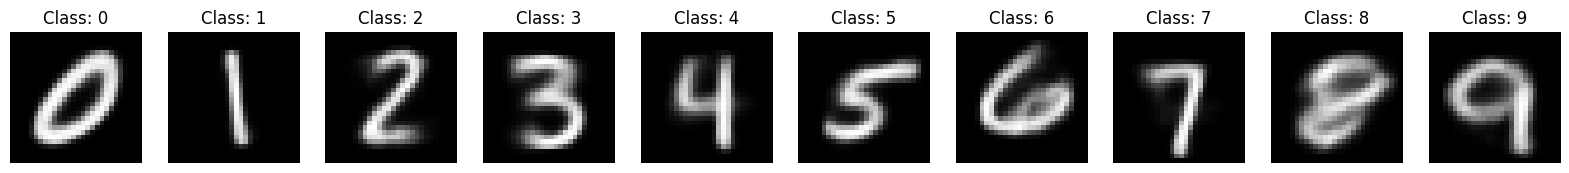

Train Epoch: 6 [0/60000 (0%)]	Loss: 120.397896
Train Epoch: 6 [3200/60000 (5%)]	Loss: 132.769104
Train Epoch: 6 [6400/60000 (11%)]	Loss: 118.753250
Train Epoch: 6 [9600/60000 (16%)]	Loss: 116.356735
Train Epoch: 6 [12800/60000 (21%)]	Loss: 126.746353
Train Epoch: 6 [16000/60000 (27%)]	Loss: 135.129166
Train Epoch: 6 [19200/60000 (32%)]	Loss: 121.125198
Train Epoch: 6 [22400/60000 (37%)]	Loss: 140.738800
Train Epoch: 6 [25600/60000 (43%)]	Loss: 132.645859
Train Epoch: 6 [28800/60000 (48%)]	Loss: 134.263428
Train Epoch: 6 [32000/60000 (53%)]	Loss: 135.992722
Train Epoch: 6 [35200/60000 (59%)]	Loss: 143.353821
Train Epoch: 6 [38400/60000 (64%)]	Loss: 128.001114
Train Epoch: 6 [41600/60000 (69%)]	Loss: 131.468597
Train Epoch: 6 [44800/60000 (75%)]	Loss: 131.116516
Train Epoch: 6 [48000/60000 (80%)]	Loss: 134.891998
Train Epoch: 6 [51200/60000 (85%)]	Loss: 141.931152
Train Epoch: 6 [54400/60000 (91%)]	Loss: 123.839569
Train Epoch: 6 [57600/60000 (96%)]	Loss: 119.086517
====> Epoch: 6 Averag

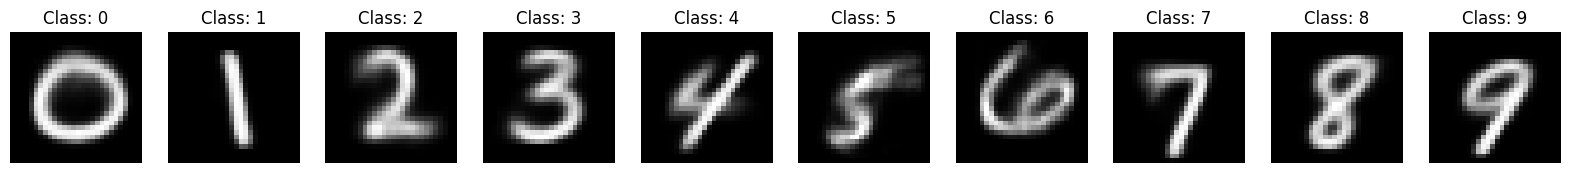

Train Epoch: 11 [0/60000 (0%)]	Loss: 128.072449
Train Epoch: 11 [3200/60000 (5%)]	Loss: 133.463196
Train Epoch: 11 [6400/60000 (11%)]	Loss: 121.624985
Train Epoch: 11 [9600/60000 (16%)]	Loss: 129.440140
Train Epoch: 11 [12800/60000 (21%)]	Loss: 141.091568
Train Epoch: 11 [16000/60000 (27%)]	Loss: 139.555878
Train Epoch: 11 [19200/60000 (32%)]	Loss: 119.760506
Train Epoch: 11 [22400/60000 (37%)]	Loss: 131.378296
Train Epoch: 11 [25600/60000 (43%)]	Loss: 119.045578
Train Epoch: 11 [28800/60000 (48%)]	Loss: 121.529488
Train Epoch: 11 [32000/60000 (53%)]	Loss: 134.637634
Train Epoch: 11 [35200/60000 (59%)]	Loss: 133.014999
Train Epoch: 11 [38400/60000 (64%)]	Loss: 128.241760
Train Epoch: 11 [41600/60000 (69%)]	Loss: 121.151932
Train Epoch: 11 [44800/60000 (75%)]	Loss: 125.065018
Train Epoch: 11 [48000/60000 (80%)]	Loss: 127.347878
Train Epoch: 11 [51200/60000 (85%)]	Loss: 137.715652
Train Epoch: 11 [54400/60000 (91%)]	Loss: 138.192245
Train Epoch: 11 [57600/60000 (96%)]	Loss: 134.956757
==

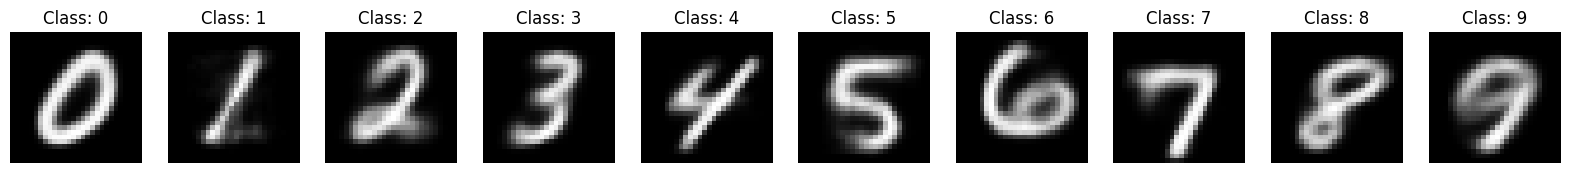

Train Epoch: 16 [0/60000 (0%)]	Loss: 132.373062
Train Epoch: 16 [3200/60000 (5%)]	Loss: 118.619690
Train Epoch: 16 [6400/60000 (11%)]	Loss: 124.722160
Train Epoch: 16 [9600/60000 (16%)]	Loss: 115.238800
Train Epoch: 16 [12800/60000 (21%)]	Loss: 129.439240
Train Epoch: 16 [16000/60000 (27%)]	Loss: 124.612885
Train Epoch: 16 [19200/60000 (32%)]	Loss: 123.260445
Train Epoch: 16 [22400/60000 (37%)]	Loss: 124.006241
Train Epoch: 16 [25600/60000 (43%)]	Loss: 141.835968
Train Epoch: 16 [28800/60000 (48%)]	Loss: 130.240738
Train Epoch: 16 [32000/60000 (53%)]	Loss: 132.091965
Train Epoch: 16 [35200/60000 (59%)]	Loss: 119.040977
Train Epoch: 16 [38400/60000 (64%)]	Loss: 121.831802
Train Epoch: 16 [41600/60000 (69%)]	Loss: 138.248886
Train Epoch: 16 [44800/60000 (75%)]	Loss: 117.499588
Train Epoch: 16 [48000/60000 (80%)]	Loss: 115.222382
Train Epoch: 16 [51200/60000 (85%)]	Loss: 121.745155
Train Epoch: 16 [54400/60000 (91%)]	Loss: 123.960365
Train Epoch: 16 [57600/60000 (96%)]	Loss: 133.646317
==

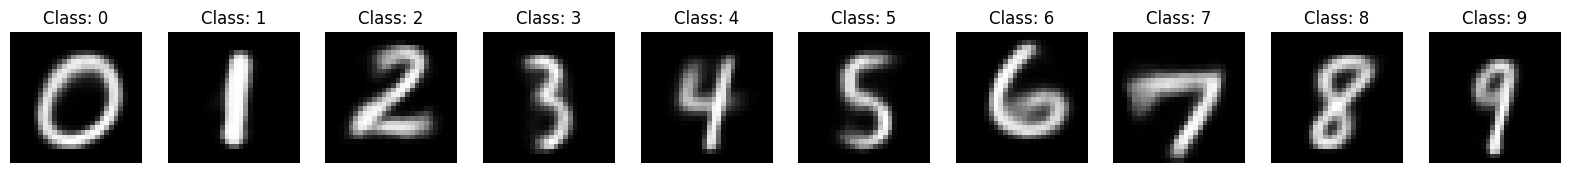

In [ ]:
# Запуск обучения
for epoch in range(1, epochs + 1):
    train(epoch)
    if epoch % 5 == 0:
        generate_samples()

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Генерация разных цифр из одного латентного вектора
def generate_same_latent_different_classes(model, latent_dim, device, num_classes=10):
    model.eval()
    with torch.no_grad():
        # Создаем ОДИН латентный вектор
        z = torch.randn(1, latent_dim).to(device)
        # Дублируем его для всех классов
        z = z.repeat(num_classes, 1)
        
        # Создаем метки классов от 0 до 9
        labels = torch.arange(0, num_classes).to(device)
        
        # Генерируем изображения
        samples = model.decode(z, labels).cpu()
        
        # Визуализация
        fig, axes = plt.subplots(1, num_classes, figsize=(20, 2))
        for i, ax in enumerate(axes):
            ax.imshow(samples[i].view(28, 28).numpy(), cmap='gray')
            ax.axis('off')
            ax.set_title(f'Class: {i}')
        plt.show()



In [ ]:

# Пример для конкретных классов (например, 5 и 7)
def generate_specific_classes_from_same_latent(model, latent_dim, device, classes=[5, 7]):
    model.eval()
    with torch.no_grad():
        # Создаем один латентный вектор
        z = torch.randn(1, latent_dim).to(device)
        # Дублируем его для нужных классов
        z = z.repeat(len(classes), 1)
        
        # Создаем метки для конкретных классов
        labels = torch.tensor(classes).to(device)
        
        # Генерируем изображения
        samples = model.decode(z, labels).cpu()
        
        # Визуализация
        fig, axes = plt.subplots(1, len(classes), figsize=(6, 2))
        for i, ax in enumerate(axes):
            ax.imshow(samples[i].view(28, 28).numpy(), cmap='gray')
            ax.axis('off')
            ax.set_title(f'Class: {classes[i]}')
        plt.show()



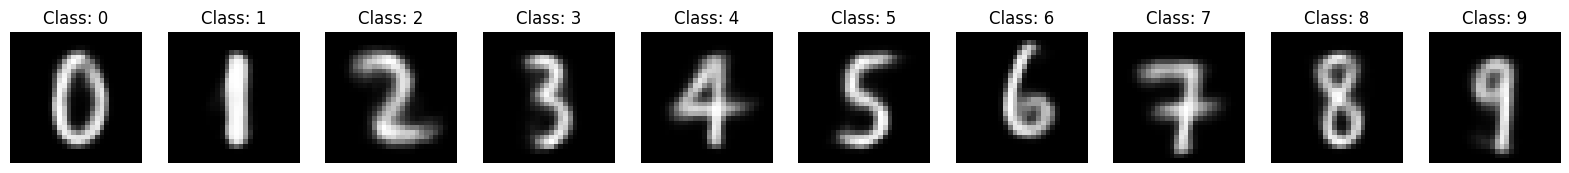

In [ ]:
generate_same_latent_different_classes(model, latent_dim, device)

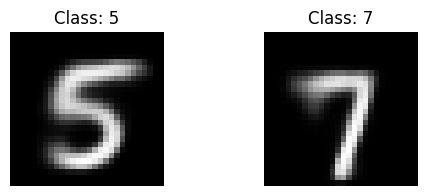

In [ ]:
# Генерируем цифры 5 и 7 из одного латентного вектора
generate_specific_classes_from_same_latent(model, latent_dim, device, classes=[5, 7])

Splendid! Вы великолепны!


> Хотя мы взяли один вектор из латентного пространства, Нам удалось восстановить изображения. Можно увидеть что все цифры обладают схожим стилем, который и определяет вектор

### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def plot_latent_2d_cvae(model, data_loader, num_batches=100, device='cuda'):
    model.eval()
    all_mu = []
    all_labels = []
    
    with torch.no_grad():
        for i, (x, y) in enumerate(data_loader):
            if i >= num_batches:
                break
                
            # Подготавливаем данные с учетом класса
            x = x.view(-1, 784).to(device)
            c = y.to(device)
            c_onehot = F.one_hot(c, num_classes=10).float()
            x_c = torch.cat([x, c_onehot], dim=1)
            
            # Получаем латентные представления
            h = model.encoder(x_c)
            mu = model.fc_mu(h)  # [batch_size, 2]
            
            all_mu.append(mu.cpu())
            all_labels.append(y.cpu())
    
    # Объединяем все батчи
    latents = torch.cat(all_mu, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    
    # Визуализация
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    plt.colorbar(scatter, ticks=range(10), label='Digit Class')
    plt.title('2D Latent Space of CVAE (colored by digit class)')
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    
    # Опционально: добавить примеры цифр в соответствующих точках
    for digit in range(10):
        idx = np.where(labels == digit)[0]
        if len(idx) > 0:
            # Берем ближайшую к центру точку для каждого класса
            center = np.mean(latents[idx], axis=0)
            dists = np.sum((latents[idx] - center)**2, axis=1)
            closest_idx = idx[np.argmin(dists)]
            
            # Вставляем пример цифры
            example = next((x for x, y in data_loader if y[0] == digit), None)
            if example is not None:
                digit_img = example[0][0].squeeze().numpy()
                imagebox = OffsetImage(digit_img, cmap='gray', zoom=0.5)
                ab = AnnotationBbox(imagebox, (latents[closest_idx, 0], latents[closest_idx, 1]), 
                                  frameon=False, pad=0)
                plt.gca().add_artist(ab)
    
    plt.grid(alpha=0.3)
    plt.show()


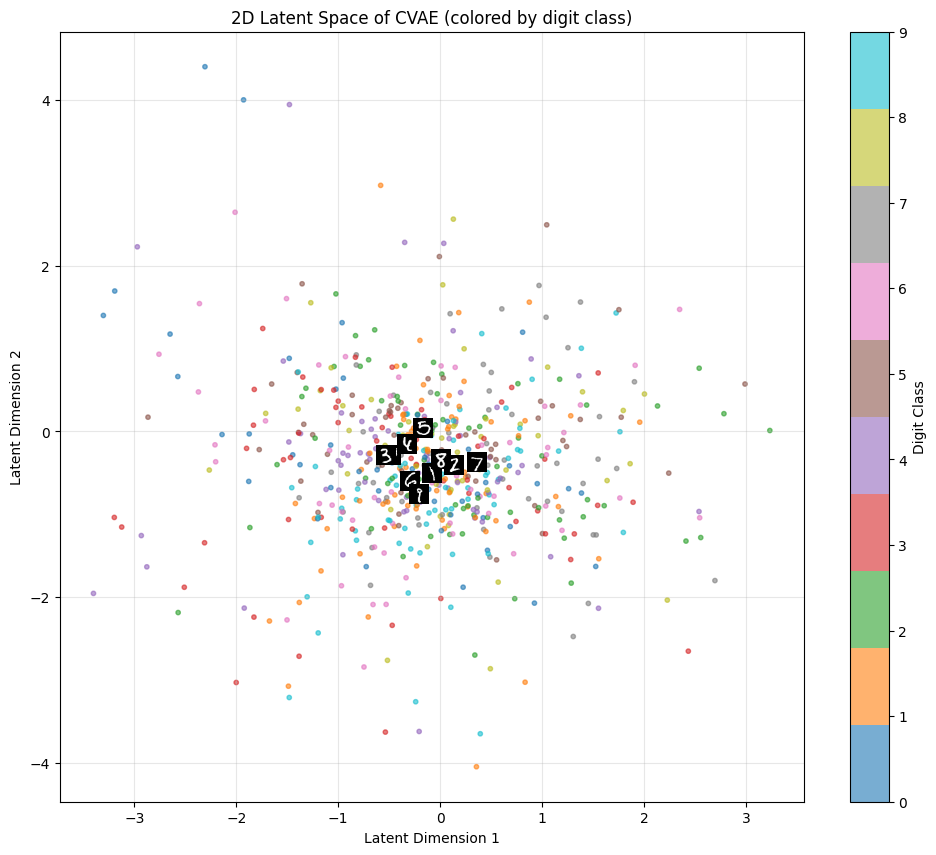

In [ ]:

# Для использования:
plot_latent_2d_cvae(model, test_loader, num_batches=20, device=device)

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

> Вектора имеют относительно равномерное распределение. Для примера расставил картинки с примерами цифр, но видно что они ни к чему не привязаны.

# BONUS 1: Denoising (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

Изменим датасет, чтобы можно было добавлять шум динамично

#### Создание датасета

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms

class NoisyAutoencoderDataset(Dataset):
    def __init__(self, images, indices, noise_factor=0.5, transform=None):
        """
        Args:
            images: numpy array в формате (N, H, W, C)
            indices: индексы для выборки
            noise_factor: коэффициент шума (0-1)
            transform: преобразования (включая ToTensor())
        """
        self.indices = indices
        self.images = images[indices]  # Выбираем данные по индексам (остаётся H x W x C)
        self.noise_factor = noise_factor
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]  # Получаем изображение в формате H x W x C

        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0  # HWC -> CHW и [0,255] -> [0,1]

        # Добавляем шум
        noisy_image = image + self.noise_factor * torch.randn_like(image)
        noisy_image = torch.clamp(noisy_image, 0., 1.)

        return noisy_image, image  # Для denoising autoencoder: (noisy, clean)

def get_denoising_dataloaders(images, batch_size=32, train_ratio=0.8, val_ratio=0.1, noise_factor=0.5):
    """
    Создает DataLoader'ы для denoising autoencoder

        images: numpy array в формате (N, H, W, C)
        noise_factor: коэффициент шума (0-1)
    """
    # Проверка формата
    if images.ndim != 4 or images.shape[3] not in {1, 3}:
        raise ValueError("Ожидается формат (N, H, W, C), где C=1 или 3")

    n_total = len(images)
    ix = np.random.choice(n_total, n_total, False)  # Перемешанные индексы
    train_size = int(train_ratio * n_total)
    val_size = int(val_ratio * n_total)
    tr, val, ts = np.split(ix, [train_size, train_size + val_size])

    # Стандартные преобразования (HWC -> CHW + нормализация)
    transform = transforms.Compose([
        transforms.ToTensor()  # Конвертирует numpy (H x W x C) в torch (C x H x W) и нормализует [0,1]
    ])

    train_dataset = NoisyAutoencoderDataset(images, tr, noise_factor=noise_factor, transform=transform)
    val_dataset = NoisyAutoencoderDataset(images, val, noise_factor=noise_factor, transform=transform)
    test_dataset = NoisyAutoencoderDataset(images, ts, noise_factor=noise_factor, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # Shuffle=True для обучения
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [29]:
train_loader, val_loader, test_loader = get_denoising_dataloaders(
    images,
    batch_size=32,
    noise_factor=0.1
)

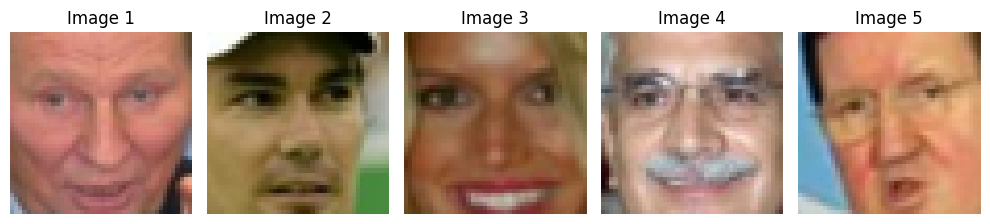

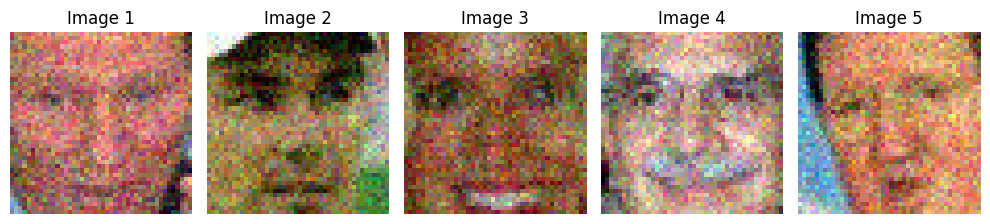

In [38]:
noisy_images, batch_images= next(iter(train_loader))  # Автоэнкодер возвращает (input, target) — берем только input

fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i in range(5):
    single_image = batch_images[i]  # Формат: (C, H, W)

    # Если изображение нормализовано в [0, 1], преобразуем в [0, 255]
    if single_image.max() <= 1.0:
        single_image = single_image * 255.0

    # Преобразуем тензор в numpy и меняем порядок осей для matplotlib (C, H, W) -> (H, W, C)
    image_np = single_image.numpy().transpose(1, 2, 0).astype(np.uint8)

    # Отображаем изображение
    axes[i].imshow(image_np)
    axes[i].axis('off')
    axes[i].set_title(f'Image {i+1}')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    single_image = noisy_images[i]  # Формат: (C, H, W)

    # Если изображение нормализовано в [0, 1], преобразуем в [0, 255]
    if single_image.max() <= 1.0:
        single_image = single_image * 255.0

    # Преобразуем тензор в numpy и меняем порядок осей для matplotlib (C, H, W) -> (H, W, C)
    image_np = single_image.numpy().transpose(1, 2, 0).astype(np.uint8)

    axes[i].imshow(image_np)
    axes[i].axis('off')  # Отключаем оси
    axes[i].set_title(f'Image {i+1}')

plt.tight_layout()
plt.show()


> Установил уровень шума в 0.1 . Если шуи больше картинки сильно искажены

#### Архитектура AE (Повторение)

In [39]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(6*6*64, 128)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(128, 6*6*64),
            nn.ReLU(),
            nn.Unflatten(1, (64, 6, 6)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=2),
            nn.AdaptiveAvgPool2d((44, 44)),  # Force the desired output size
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code


In [42]:
from torch import optim


def train_denoising_ae(model, train_loader, val_loader, epochs=50, lr=0.001, device='cuda'):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for noisy_imgs, clean_imgs in train_loader:
            noisy_imgs = noisy_imgs.to(device)
            clean_imgs = clean_imgs.to(device)

            optimizer.zero_grad()
            outputs, _ = model(noisy_imgs)
            loss = criterion(outputs, clean_imgs)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * noisy_imgs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for noisy_imgs, clean_imgs in val_loader:
                noisy_imgs = noisy_imgs.to(device)
                clean_imgs = clean_imgs.to(device)

                outputs, _ = model(noisy_imgs)
                loss = criterion(outputs, clean_imgs)
                val_loss += loss.item() * noisy_imgs.size(0)

        val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f'Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')

    return train_losses, val_losses


#### Обучение

In [44]:
model = Autoencoder()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_losses, val_losses = train_denoising_ae(model, train_loader, val_loader, epochs=20, device=device)

torch.save(model.state_dict(), 'denoising_autoencoder.pth')

Epoch 1/20 - Train Loss: 0.0192, Val Loss: 0.0091
Epoch 2/20 - Train Loss: 0.0078, Val Loss: 0.0066
Epoch 3/20 - Train Loss: 0.0060, Val Loss: 0.0057
Epoch 4/20 - Train Loss: 0.0052, Val Loss: 0.0049
Epoch 5/20 - Train Loss: 0.0046, Val Loss: 0.0045
Epoch 6/20 - Train Loss: 0.0043, Val Loss: 0.0042
Epoch 7/20 - Train Loss: 0.0040, Val Loss: 0.0039
Epoch 8/20 - Train Loss: 0.0038, Val Loss: 0.0038
Epoch 9/20 - Train Loss: 0.0035, Val Loss: 0.0035
Epoch 10/20 - Train Loss: 0.0034, Val Loss: 0.0035
Epoch 11/20 - Train Loss: 0.0033, Val Loss: 0.0033
Epoch 12/20 - Train Loss: 0.0032, Val Loss: 0.0032
Epoch 13/20 - Train Loss: 0.0031, Val Loss: 0.0031
Epoch 14/20 - Train Loss: 0.0030, Val Loss: 0.0031
Epoch 15/20 - Train Loss: 0.0029, Val Loss: 0.0029
Epoch 16/20 - Train Loss: 0.0028, Val Loss: 0.0028
Epoch 17/20 - Train Loss: 0.0027, Val Loss: 0.0028
Epoch 18/20 - Train Loss: 0.0027, Val Loss: 0.0028
Epoch 19/20 - Train Loss: 0.0026, Val Loss: 0.0027
Epoch 20/20 - Train Loss: 0.0026, Val Lo

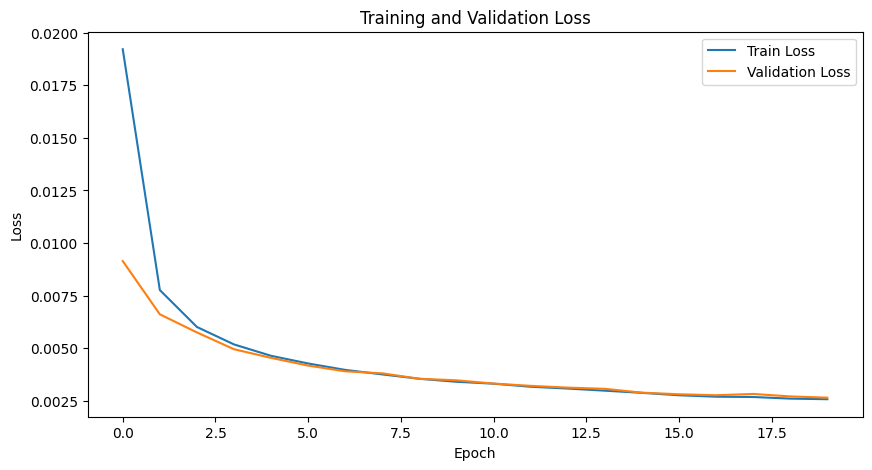

In [47]:
# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

> Изменение результата функции потерь отсутствует на уровне 10 эпох

#### Визуализация результата восстановления изображений с шумом

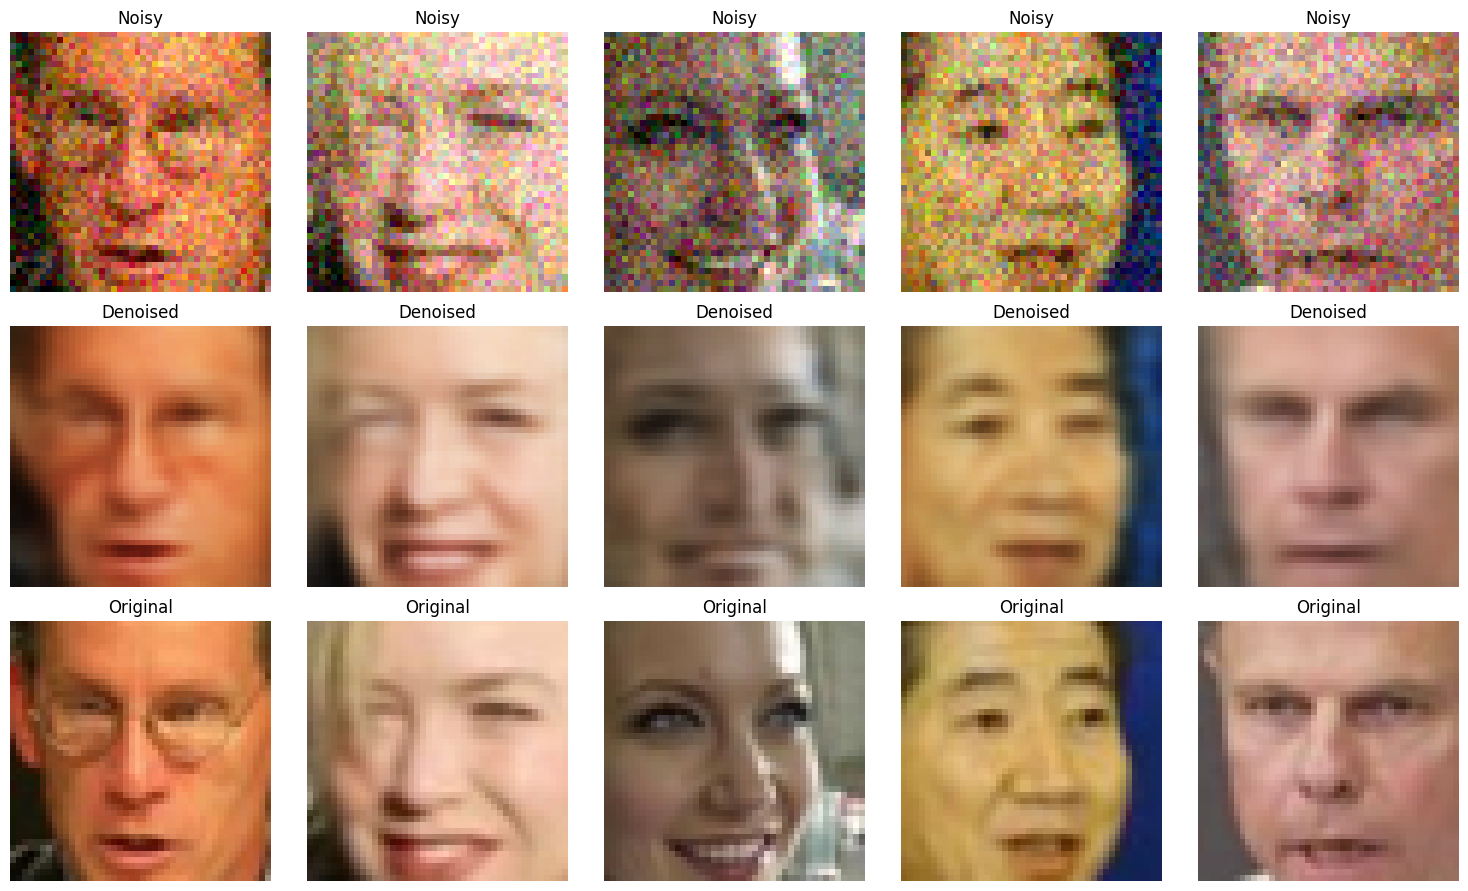

In [48]:
model.eval()
with torch.no_grad():
    # Get a batch of validation data
    noisy_imgs, clean_imgs = next(iter(val_loader))
    noisy_imgs = noisy_imgs.to(device)
    clean_imgs = clean_imgs.to(device)

    # Get model predictions
    denoised_imgs, _ = model(noisy_imgs)

    # Convert to numpy for visualization
    noisy_imgs = noisy_imgs.cpu().numpy()
    clean_imgs = clean_imgs.cpu().numpy()
    denoised_imgs = denoised_imgs.cpu().numpy()

    # Plot some examples
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    for i in range(5):
        axes[0, i].imshow(np.transpose(noisy_imgs[i], (1, 2, 0)))
        axes[0, i].set_title('Noisy')
        axes[0, i].axis('off')

        axes[1, i].imshow(np.transpose(denoised_imgs[i], (1, 2, 0)))
        axes[1, i].set_title('Denoised')
        axes[1, i].axis('off')

        axes[2, i].imshow(np.transpose(clean_imgs[i], (1, 2, 0)))
        axes[2, i].set_title('Original')
        axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()

> Модель хорошо восстанавливает изображения из картинок с шумом. Наблюдается замыленность, но это оссобенность AE.

# BONUS 2: Image Retrieval (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [9]:
train_loader, val_loader, test_loader = get_dataloaders(images, batch_size=64)

### VAE для картинок лиц

In [112]:
class VariationalEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.input_dim = 44 * 44 * 3
        self.linear1 = nn.Linear(self.input_dim, 1024)
        self.linear2 = nn.Linear(1024, latent_dims)  # mu
        self.linear3 = nn.Linear(1024, latent_dims)  # log(sigma)

        self.N = torch.distributions.Normal(0, 1)
        self.kl = 0

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu = self.linear2(x)
        log_sigma = self.linear3(x)
        sigma = torch.exp(log_sigma)
        z = mu + sigma * self.N.sample(mu.shape).to(x.device)
        self.kl = (sigma ** 2 + mu ** 2 - log_sigma - 1).sum() * 0.5
        return z


In [113]:
class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.output_dim = 44 * 44 * 3
        self.linear1 = nn.Linear(latent_dims, 1024)
        self.linear2 = nn.Linear(1024, self.output_dim)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = torch.sigmoid(self.linear2(z))
        return z.view(-1, 3, 44, 44)


In [114]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = VariationalEncoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


In [115]:
def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())
    autoencoder.train()

    for epoch in range(epochs):
        epoch_loss = 0.0
        num_batches = 0

        for x, _ in data:
            x = x.to(device)
            opt.zero_grad()
            x_hat = autoencoder(x)
            loss = ((x - x_hat) ** 2).sum() + autoencoder.encoder.kl
            loss.backward()
            opt.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        print(f'Epoch: {epoch}, Loss: {avg_loss:.4f}')

    return autoencoder


### Обучение VAE

In [116]:
latent_dims = 64

In [117]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [118]:
vae = VariationalAutoencoder(latent_dims).to(device)  # GPU
vae = train(vae, train_loader, epochs=20)

Epoch: 0, Loss: 8035.5958
Epoch: 1, Loss: 5795.2024
Epoch: 2, Loss: 5111.9922
Epoch: 3, Loss: 4792.0584
Epoch: 4, Loss: 4430.3766
Epoch: 5, Loss: 4213.4804
Epoch: 6, Loss: 4092.2441
Epoch: 7, Loss: 3942.1247
Epoch: 8, Loss: 3868.8301
Epoch: 9, Loss: 3821.6907
Epoch: 10, Loss: 3695.9313
Epoch: 11, Loss: 3654.4971
Epoch: 12, Loss: 3585.4575
Epoch: 13, Loss: 3546.2735
Epoch: 14, Loss: 3539.6252
Epoch: 15, Loss: 3469.8635
Epoch: 16, Loss: 3442.8240
Epoch: 17, Loss: 3432.2100
Epoch: 18, Loss: 3406.2975
Epoch: 19, Loss: 3376.3334


Проверим как работает реконструкция

In [119]:
def show_reconstructions(autoencoder, dataloader, device, num_images=8):
    autoencoder.eval()
    images_shown = 0

    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            x_hat = autoencoder(x)

            x = x.cpu().numpy()
            x_hat = x_hat.cpu().numpy()

            for i in range(num_images):
                fig, axes = plt.subplots(1, 2, figsize=(4, 2))
                # Original
                axes[0].imshow(x[i].transpose(1, 2, 0))
                axes[0].set_title('Original')
                axes[0].axis('off')

                # Reconstruction
                axes[1].imshow(x_hat[i].transpose(1, 2, 0))
                axes[1].set_title('Reconstruction')
                axes[1].axis('off')

                plt.show()
                images_shown += 1

            break  # Показываем только один батч


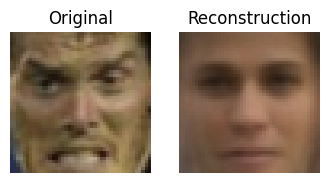

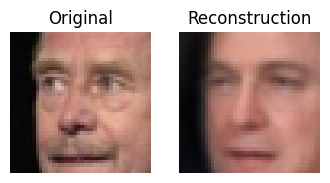

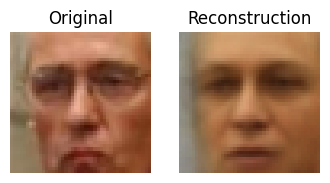

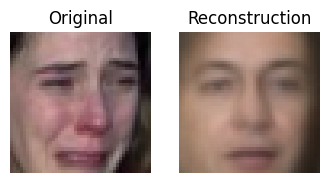

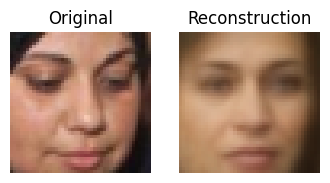

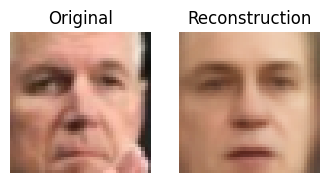

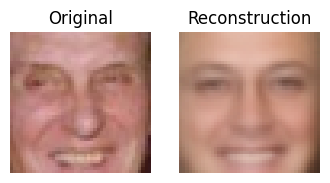

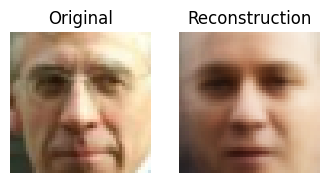

In [120]:
show_reconstructions(vae, test_loader, device='cpu')

### Выделим все вектора из латентного пространства

In [121]:
def extract_latent_vectors(autoencoder, dataloader, device):
    autoencoder.eval()
    latents = []

    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            z = autoencoder.encoder(x)  # только кодирование
            latents.append(z.cpu())

    # Объединяем в один тензор
    latents = torch.cat(latents, dim=0)
    return latents

In [122]:
latents = extract_latent_vectors(vae, train_loader, device='cpu')
print(latents.shape)  # например: torch.Size([10000, latent_dim])


torch.Size([10514, 64])


### Обучение KNN для латентных векторов

In [123]:
from sklearn.neighbors import NearestNeighbors

# latents: [N, latent_dim]
nbrs = NearestNeighbors(n_neighbors=5, algorithm='auto', metric='euclidean').fit(latents)
distances, indices = nbrs.kneighbors(latents[:10])  # ищем для первых 10
print("Индексы ближайших:", indices)
print("Расстояния:", distances)

Индексы ближайших: [[   0 4541 6677 1669 2553]
 [   1  546 2065 6748   46]
 [   2 9771 2994 5127 8944]
 [   3 7587  538 1852 2090]
 [   4 7460  384 8985 9145]
 [   5 3788 8950  754 2364]
 [   6 7702 8037 2905  546]
 [   7 4623 1672 1223 7351]
 [   8 2708 1460 9767 3184]
 [   9 3135 4667  951 8500]]
Расстояния: [[1.19209290e-07 5.31665850e+00 5.39944935e+00 5.59374142e+00
  5.62406731e+00]
 [1.19209290e-07 4.96984148e+00 5.22679567e+00 5.28594828e+00
  5.34082699e+00]
 [1.19209290e-07 5.55858755e+00 5.73038769e+00 5.74961758e+00
  5.81896353e+00]
 [0.00000000e+00 5.40432882e+00 5.41305685e+00 5.51564312e+00
  5.56189442e+00]
 [0.00000000e+00 5.88498116e+00 6.09963417e+00 6.10610580e+00
  6.11977005e+00]
 [1.68587391e-07 5.85702515e+00 5.92330170e+00 6.02766514e+00
  6.16427088e+00]
 [1.19209290e-07 5.36857557e+00 5.46945667e+00 5.60606146e+00
  5.62770748e+00]
 [8.42936956e-08 5.36704969e+00 5.38333511e+00 5.45602608e+00
  5.45781708e+00]
 [0.00000000e+00 5.28633118e+00 5.37790680e+00 5

### Поиск похожих

In [128]:
def get_similar(image, autoencoder, knn_model, X_train, n_neighbors=5, device='cpu'):
    autoencoder.eval()

    # Переводим image в формат батча и на нужное устройство
    x = image.unsqueeze(0).to(device)

    with torch.no_grad():
        # Получаем латентный вектор
        code = autoencoder.encoder(x).cpu().numpy()

    # Поиск ближайших
    distances, indices = knn_model.kneighbors(code, n_neighbors=n_neighbors)

    # Получаем соответствующие изображения
    similar_images = torch.stack([X_train.dataset[i][0] for i in indices[0]])

    return distances[0], similar_images


In [166]:
n_neighbors = 5
knn_model = NearestNeighbors(n_neighbors=n_neighbors, algorithm='auto').fit(latents.numpy())

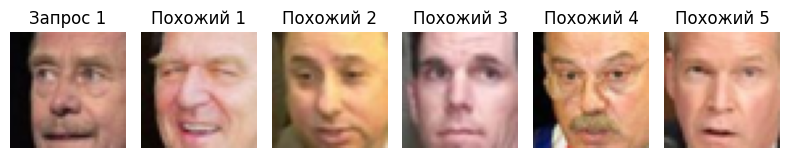

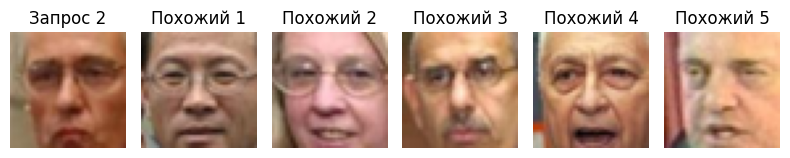

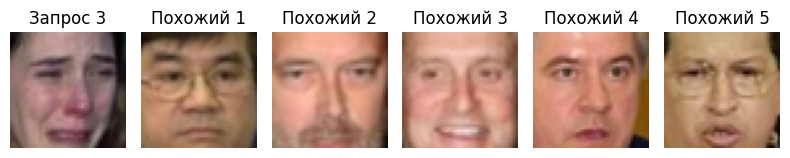

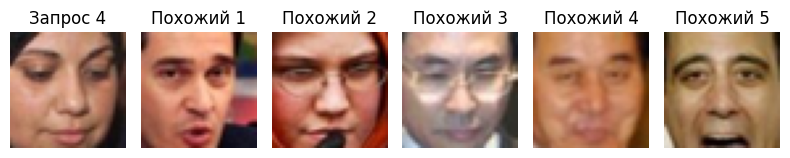

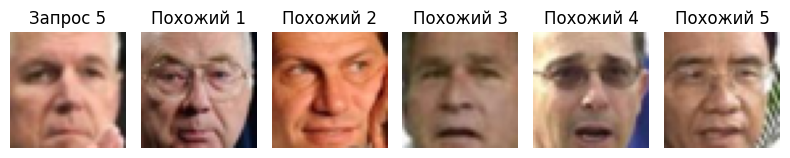

In [169]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img, _ = next(iter(test_loader))  # одна картинка из теста
map = {1: {3}, 3: {4}, 4: {2}, 5: {2, 3}}

for idx in range(1, 5 + 1):
    image = img[idx]
    distances, neighbors = get_similar(image, vae, knn_model, train_loader, device=device)

    plt.figure(figsize=(8, 2))

    ax = plt.subplot(1, n_neighbors + 1, 1)
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"Запрос {idx}")
    ax.axis('off')

    # Похожие картинки
    for i in range(n_neighbors):
        ax_sim = plt.subplot(1, n_neighbors + 1, i + 2)
        ax_sim.imshow(neighbors[i].permute(1, 2, 0))
        ax_sim.set_title(f"Похожий {i + 1}")
        ax_sim.axis('off')

    plt.tight_layout()
    plt.show()


> Модель довольно хорошо улавливает часть особенностей изображения. Возможно точно похожих картинок мало, но поиск работает эффективно даже с первого раза.